**Research Question:** "Among self-reported actual-use reporter-drug pairs in the v2 probe, what symptom-specific outcome heterogeneity and adverse-event patterns are reported, and how robust are they to extraction and reporter clustering?"

# Patient experience in the v2 psychedelics probe

**Abstract.** This notebook describes symptom-specific outcome heterogeneity and adverse-event
patterns in extracted reports for psilocybin, ketamine, and LSD. The source run contains
1,157 cohort reporter-drug pairs from 1,041 reporter accounts and 2,921 included claims, all of
which are self-reported actual use by the schema's own inclusion rule. Helped directions dominate
the extracted effect records overall, but they are not uniform across symptom classes: reporting
of benefit is markedly lower for **nonspecific fatigue** than for mood/cognitive, most sharply
under ketamine, and benefit-plus-harm and no-effect experiences remain visible throughout.
**No post-exertional-malaise result is reported.** The v1 `energy_pem` class merged explicit PEM
with ordinary fatigue and low energy under one pattern; separated out, explicit-PEM targets are
too few to clear the evidence gate for any drug, so the fatigue finding is stated as a fatigue
finding and nothing here is called PEM.

**The analysis unit is a Reddit account, not a verified person** (§1), and reader-facing counts
are counts of accounts.

**This notebook reports no p-values and performs no hypothesis tests.** Every comparison is
stated as a rate difference in percentage points with a reporter-clustered bootstrap interval and
an effect size, ranked by magnitude and gated on a minimum evidence threshold. **Each headline
contrast moves one factor** — a symptom class against the same drug's other classes, or a drug
against the other drugs inside the same class — rather than against an omnibus "rest of corpus"
reference that changes drug, symptom, route and reporter mix at once; a drug-by-symptom
interaction model is reported alongside. No equivalence
test is performed either, so overlapping intervals are never described as showing that two drugs
are the same. Adverse-event shares describe reports, not incidence. Route of administration is
reported for ketamine only, as a **stated route** and not as an administration setting, which
this run does not measure; LSD numeric dosing is reported as **insufficient data** rather than
binned into a result. All conclusions remain hypothesis-generating because the cohort is
selected, extraction is not human-validated, and no control arm exists. The practical
recommendation is to treat symptom-specific and harm-aware reporting patterns as signals for
validation, not as patient-specific treatment advice.

## 1. Scope, unit of analysis, and privacy boundary

The unit for headline outcome estimates is a **reporter-drug pair**, and the symptom map
aggregates first to a reporter-drug-symptom-class row. This prevents multiple claims from one
account from being treated as independent observations. The report distinguishes:

- the asserted cohort pairs, planned and completed extraction units, and included claims;
- effect-bearing and adverse-event-bearing reporter-drug pairs;
- individual effect, adverse-event, and dose records used only for coverage and composition.

**On the word "reporter".** The analysis unit is a **Reddit account**, not a verified person.
The loader maps each `author_hash` to a dense integer id; that id verifies neither identity nor
one-account-per-person, so shared accounts, one person holding several accounts, and
misattributed self-reports all remain possible and unmeasured. Counts such as "1,041" are counts
of accounts. `subject=self` is a **claim-level inclusion condition applied by the extraction
schema** — the model's reading that a passage describes its author's own use — and not external
identity verification. Nothing in this notebook establishes that a reporter is a reporter, so the
word "patient" is not used for these ids anywhere in the reader-facing text.

**On the actual-use population.** The extraction schema admits a claim only when
`subject=self` **and** `exposure_status=actual_use`, so `included` and "self-reported actual
use" are the same 2,921 claims. Earlier drafts applied that filter a second time and described
it as a restriction; it removes nothing, and the next cell asserts the identity rather than
implying a narrowing that does not occur.

**On inference.** No p-value, chi-squared test, Fisher test, or false-discovery-rate adjustment
appears in this notebook. Rows here are clustered inside reporter accounts and, in the
cross-symptom comparisons, the same account appears on both sides of a contrast — conditions that
the usual independence-assuming tests do not meet. Comparisons are therefore reported as rate
differences with **reporter-clustered bootstrap intervals**, in which whole accounts are resampled
so that an account contributing to both arms stays intact, alongside Cohen's *h* as a scale-free
effect size. Intervals are descriptive uncertainty ranges, not decision rules.

All estimates describe extractable Reddit reporting patterns, not the risk or benefit among
people exposed to any drug. The existing `psychedelics_v2.load_frames()` loader is the only
reader used here. It never selects quote-bearing fields or author hashes, maps free-text dose
fields to closed vocabularies, and discards potentially source-echoing validation errors.
This notebook is a private-review artifact and contains no verbatim Reddit quotes.

In [1]:
import hashlib
import html
import sys
import zlib
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import HTML, display

# ── Database location (read-only) ──
import os

DB_PATH = os.environ.get("PP_PROBE_DB")
if DB_PATH:
    DB_PATH = str(Path(DB_PATH).expanduser().resolve())
else:
    _repo = next(
        p for p in [Path.cwd(), *Path.cwd().parents]
        if (p / "data/probes/psychedelic_pharmacology.db").is_file()
    )
    DB_PATH = str((_repo / "data/probes/psychedelic_pharmacology.db").resolve())
if not Path(DB_PATH).is_file():
    raise FileNotFoundError(f"Database not found: {DB_PATH}")

# ── Reproducibility ──
# Python's hash() is salted per process, so hash()-derived seeds are not stable
# across runs. crc32 is, so every interval in this notebook is reproducible.
BASE_SEED = 20260809
N_BOOT = 2000


def seed_for(*parts):
    """Deterministic bootstrap seed, stable across processes."""
    return (BASE_SEED + zlib.crc32("|".join(map(str, parts)).encode())) % 2**32


# ── Evidence gate ──
# Cells below these thresholds are reported as insufficient rather than
# interpreted; a rate over a handful of rows is not a rate worth a headline.
MIN_ROWS = 20
MIN_PATIENTS = 10


def meets_gate(n_rows, n_patients):
    return bool(n_rows >= MIN_ROWS and n_patients >= MIN_PATIENTS)


# ── Effect size and clustered intervals ──

def cohens_h(p1, p2):
    """Scale-free difference between two proportions (arcsine transform)."""
    if pd.isna(p1) or pd.isna(p2):
        return np.nan
    return 2 * np.arcsin(np.sqrt(np.clip(p1, 0, 1))) - 2 * np.arcsin(np.sqrt(np.clip(p2, 0, 1)))


def _patient_totals(frame, indicator, patients):
    """Per-patient (sum, count) of a boolean indicator, aligned on `patients`."""
    grouped = (frame.groupby("patient")[indicator].agg(["sum", "count"])
               .reindex(patients).fillna(0))
    return grouped["sum"].to_numpy(float), grouped["count"].to_numpy(float)


def _ratio(sums, counts, index):
    numerator = sums[index].sum(axis=1)
    denominator = counts[index].sum(axis=1)
    return np.divide(numerator, denominator,
                     out=np.full(len(numerator), np.nan), where=denominator > 0)


def clustered_rate(frame, indicator, seed=BASE_SEED, n_boot=N_BOOT):
    """Rate over rows, with a 95% interval from resampling whole patients."""
    sub = frame[["patient", indicator]].dropna()
    if sub.empty:
        return np.nan, np.nan, np.nan
    patients = np.array(sorted(sub["patient"].unique()))
    sums, counts = _patient_totals(sub, indicator, patients)
    point = sums.sum() / counts.sum()
    if len(patients) < 2:
        return point, np.nan, np.nan
    index = np.random.default_rng(seed).integers(0, len(patients), (n_boot, len(patients)))
    boot = _ratio(sums, counts, index)
    return point, float(np.nanquantile(boot, 0.025)), float(np.nanquantile(boot, 0.975))


def clustered_difference(frame, indicator, mask, seed=BASE_SEED, n_boot=N_BOOT):
    """Rate difference (focal vs reference) with a reporter-clustered interval.

    The reference arm is whatever `frame` contains outside `mask`, so the caller
    chooses the comparison by choosing the frame. Both arms are recomputed from a
    single resample of whole accounts, so an account with rows on both sides is
    never split — the dependence between the arms is carried into the interval
    instead of being assumed away.
    """
    sub = frame.loc[frame[indicator].notna(), ["patient", indicator]]
    inside, outside = sub[mask.loc[sub.index]], sub[~mask.loc[sub.index]]
    if inside.empty or outside.empty:
        return {}
    patients = np.array(sorted(sub["patient"].unique()))
    sums_in, counts_in = _patient_totals(inside, indicator, patients)
    sums_out, counts_out = _patient_totals(outside, indicator, patients)
    rate_in = inside[indicator].mean()
    rate_out = outside[indicator].mean()
    index = np.random.default_rng(seed).integers(0, len(patients), (n_boot, len(patients)))
    boot = _ratio(sums_in, counts_in, index) - _ratio(sums_out, counts_out, index)
    return {
        "rate (focal)": rate_in,
        "rate (reference)": rate_out,
        "difference (pp)": 100 * (rate_in - rate_out),
        "diff low": 100 * float(np.nanquantile(boot, 0.025)),
        "diff high": 100 * float(np.nanquantile(boot, 0.975)),
        "Cohen h": cohens_h(rate_in, rate_out),
        "focal rows": len(inside),
        "focal patients": inside["patient"].nunique(),
        "reference rows": len(outside),
        "reference patients": outside["patient"].nunique(),
    }


def interval_note(low, high):
    """Where a difference interval sits relative to no difference."""
    if pd.isna(low) or pd.isna(high):
        return "no interval"
    if low > 0:
        return "interval above 0"
    if high < 0:
        return "interval below 0"
    return "interval spans 0"


def direction_profile(row):
    helped, worsened, none, mixed = row["helped"], row["worsened"], row["no_effect"], row["mixed"]
    if helped and not (worsened or none or mixed):
        return "helped only"
    if worsened and not (helped or none or mixed):
        return "worsened only"
    if none and not (helped or worsened or mixed):
        return "no effect only"
    return "mixed / conflicting"


# ── Chart defaults ──
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11
DRUG_COLORS = {"psilocybin": "#2b6cb0", "ketamine": "#dd6b20", "lsd": "#805ad5"}

In [2]:
sys.path.insert(0, str(Path(DB_PATH).resolve().parents[2] / "studies/psychedelics/v2"))
import psychedelics_v2 as P

P.apply_style(plt)
RUN_ID = "710567555e22b68c025d8ceb1c3373564d7f9b01dcc5fe94b02b7c3209ecbc05"
f = P.load_frames(Path(DB_PATH), run_id=RUN_ID)
cfg = f.run["config"]
execution_date = datetime.now(timezone.utc).date().isoformat()
db_sha256 = hashlib.sha256(Path(DB_PATH).read_bytes()).hexdigest()
source_snapshot = "reddit_2026-06-13.db (source snapshot documented by the v2 run)"

# The schema admits a claim only for self-reported actual use, so `included`
# already IS the actual-use population. Assert it instead of re-filtering.
included = f.claims[f.claims["included"]].copy()
assert (included["subject"].eq("self") & included["exposure_status"].eq("actual_use")).all(), \
    "included claims are no longer identical to self-reported actual use"
actual_claims = included
actual_claim_ids = set(actual_claims["claim_id"])

effects = f.effects[f.effects["claim_id"].isin(actual_claim_ids)].copy()
adverse = f.adverse[f.adverse["claim_id"].isin(actual_claim_ids)].copy()
doses = f.doses[f.doses["claim_id"].isin(actual_claim_ids)].copy()
cohort_pairs = f.members[["patient", "drug"]].drop_duplicates()
actual_pairs = actual_claims[["patient", "drug"]].drop_duplicates()

DRUGS = list(P.DRUGS)
DIRECTIONS = list(P.DIRECTIONS)
# Display order groups the four classes the v1 `energy_pem` composite merged.
SYMPTOMS = ["pem_explicit", "exertion_intolerance", "fatigue_general", "low_energy",
            "mood_cognitive", "pain", "other", "unspecified"]
assert set(SYMPTOMS) == set(P.SYMPTOM_CLASSES), "display order is missing a symptom class"
ROUTE_DRUG = "ketamine"   # route is interpreted for ketamine only — see §7
duration_labels = {
    "acute_session": "acute / short-lived",
    "under_24_hours": "acute / short-lived",
    "one_to_six_days": "intermediate",
    "one_to_four_weeks": "intermediate",
    "one_to_six_months": "long-lasting",
    "over_six_months": "long-lasting",
    "ongoing_at_report": "ongoing at report",
}
print(f"included claims = self-reported actual use: {len(actual_claims):,} claims, "
      f"{len(actual_pairs):,} reporter-drug pairs")

included claims = self-reported actual use: 2,921 claims, 953 reporter-drug pairs


### Data provenance and run configuration

**Snapshot date: 2026-06-13.** This is the date carried by the source snapshot's *name*, not
the period over which the underlying posts were written. The loader does not read post
timestamps, so **the content date range is unavailable** and nothing here should be read as
covering a one-day window — or any known window. Recovering it would require deliberately
loading timestamps under the privacy contract.
The cohort was imported from the legacy pipeline's asserted cohort. The earlier v2 analysis
records that the reconciliation gate was therefore skipped: the 1,157-pair match is true by
construction and does not independently confirm the cohort. The same analysis records a
mechanical grounding floor but no item-level human validation. These facts are carried forward
because extraction quality affects every downstream pattern.

**Reproducing this notebook.** The run is pinned by full id rather than chosen
implicitly — a database holding more than one run would otherwise be resolved by
whichever row came back first. To re-execute, point `PP_PROBE_DB` at a database whose
SHA-256 matches the provenance table below and whose `probe_run` contains
`RUN_ID` as set in the setup cell; the loader raises if that run is absent or not
unique.

Bootstrap seeds are derived with `crc32`, not Python's per-process-salted `hash()`, so every
interval below reproduces exactly on re-execution. The seed and resample count are recorded in
the provenance table.

In [3]:
provenance = pd.DataFrame([
    {"item": "database", "value": Path(DB_PATH).name},
    {"item": "database SHA-256", "value": db_sha256},
    {"item": "run ID (pinned)", "value": f.run["run_id"]},
    {"item": "run created", "value": f.run["created_at"]},
    {"item": "model", "value": cfg.get("model")},
    {"item": "provider / base URL", "value": f"{cfg.get('provider')} / {cfg.get('base_url')}"},
    {"item": "source snapshot", "value": source_snapshot},
    {"item": "source snapshot date", "value": "2026-06-13 (the date in the snapshot name)"},
    {"item": "content date range", "value": "unavailable — post timestamps are not loaded"},
    {"item": "execution date (UTC)", "value": execution_date},
    {"item": "loader", "value": "studies/psychedelics/v2/psychedelics_v2.py"},
    {"item": "inference", "value": "no p-values; reporter-clustered bootstrap intervals only"},
    {"item": "bootstrap", "value": f"{N_BOOT:,} resamples of whole reporter accounts, base seed {BASE_SEED}"},
    {"item": "evidence gate", "value": f"≥{MIN_ROWS} rows and ≥{MIN_PATIENTS} reporter accounts"},
    {"item": "skill version", "value": "research-assistant v2"},
])
row_counts = pd.DataFrame([
    {"table/frame": "cohort pairs (members)", "rows": len(f.members)},
    {"table/frame": "planned units", "rows": len(f.units)},
    {"table/frame": "attempts", "rows": len(f.attempts)},
    {"table/frame": "claims", "rows": len(f.claims)},
    {"table/frame": "included = actual-use claims", "rows": len(actual_claims)},
    {"table/frame": "effects", "rows": len(f.effects)},
    {"table/frame": "adverse events", "rows": len(f.adverse)},
    {"table/frame": "doses", "rows": len(f.doses)},
])
display(provenance.style.hide(axis="index").set_properties(**{"text-align": "left"}))
display(row_counts.style.hide(axis="index"))

item,value
database,psychedelic_pharmacology.db
database SHA-256,2edbe6136ec8c451e486ecd3d3b19cbdf1ed2e78e47a07c5a808f8cf137f96cc
run ID (pinned),710567555e22b68c025d8ceb1c3373564d7f9b01dcc5fe94b02b7c3209ecbc05
run created,2026-08-09T22:30:11.041289+00:00
model,deepseek/deepseek-v4-flash
provider / base URL,openai / https://openrouter.ai/api
source snapshot,reddit_2026-06-13.db (source snapshot documented by the v2 run)
source snapshot date,2026-06-13 (the date in the snapshot name)
content date range,unavailable — post timestamps are not loaded
execution date (UTC),2026-08-10


table/frame,rows
cohort pairs (members),1157
planned units,1206
attempts,1439
claims,3982
included = actual-use claims,2921
effects,2890
adverse events,472
doses,1338


## 2. Reporting funnel and missingness

The extraction path has several different denominators. A completed unit is an extraction
unit, whereas an included claim is a claim event and an effect-bearing pair is a reporter-drug
pair. These are not interchangeable. 953 of the 1,157 cohort pairs carry at least one included
claim — and because inclusion *is* the actual-use rule, that is also the actual-use population.
Silence in a downstream field is missing information, not evidence that the event or field was
absent.

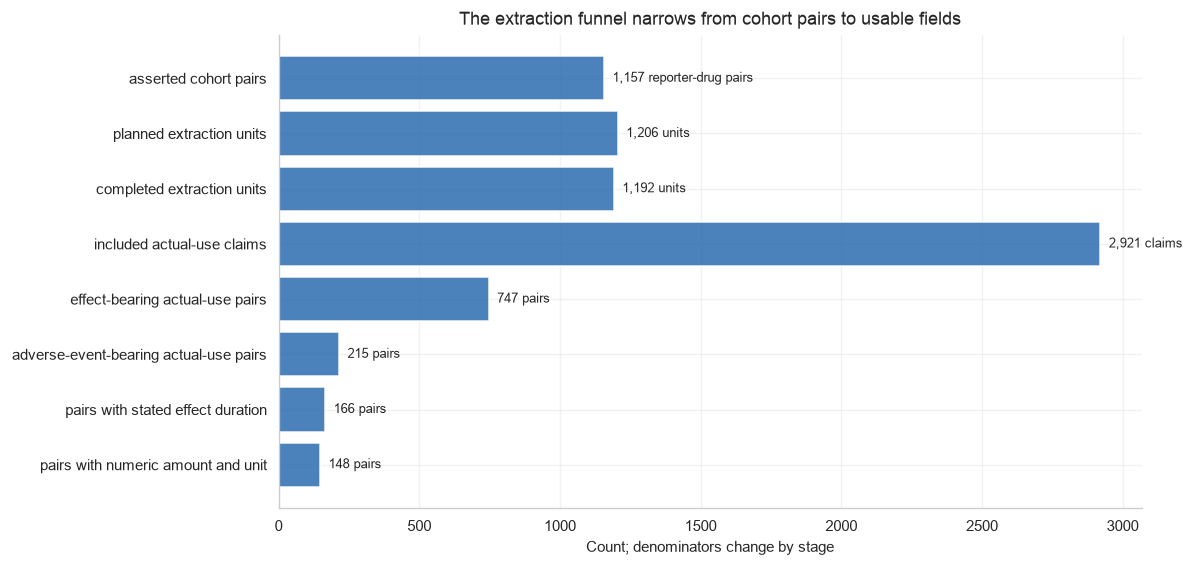

In [4]:
effect_pairs = effects[["patient", "drug"]].drop_duplicates()
ae_pairs = adverse[["patient", "drug"]].drop_duplicates()
duration_effect_pairs = effects.loc[
    effects["duration_bin"].notna(), ["patient", "drug"]
].drop_duplicates()
numeric_dose_pairs = doses.loc[
    doses["amount_lower"].notna() & doses["unit_canon"].notna(),
    ["patient", "drug"],
].drop_duplicates()
funnel = pd.DataFrame([
    {"stage": "asserted cohort pairs", "count": len(cohort_pairs), "unit": "reporter-drug pairs"},
    {"stage": "planned extraction units", "count": len(f.units), "unit": "units"},
    {"stage": "completed extraction units", "count": int(f.units["status"].eq("complete").sum()), "unit": "units"},
    {"stage": "included actual-use claims", "count": len(actual_claims), "unit": "claims"},
    {"stage": "effect-bearing actual-use pairs", "count": len(effect_pairs), "unit": "pairs"},
    {"stage": "adverse-event-bearing actual-use pairs", "count": len(ae_pairs), "unit": "pairs"},
    {"stage": "pairs with stated effect duration", "count": len(duration_effect_pairs), "unit": "pairs"},
    {"stage": "pairs with numeric amount and unit", "count": len(numeric_dose_pairs), "unit": "pairs"},
])
fig, ax = plt.subplots(figsize=(10, 4.8))
plot_funnel = funnel.iloc[::-1]
y = np.arange(len(plot_funnel))
ax.barh(y, plot_funnel["count"], color="#2b6cb0", alpha=0.85)
ax.set_yticks(y, plot_funnel["stage"])
ax.set_xlabel("Count; denominators change by stage")
ax.set_title("The extraction funnel narrows from cohort pairs to usable fields")
for yi, (_, r) in zip(y, plot_funnel.iterrows()):
    ax.annotate(f"{r['count']:,} {r['unit']}", (r["count"], yi), xytext=(5, 0),
                textcoords="offset points", va="center", fontsize=8)
fig.tight_layout()
display(fig)
plt.close(fig)


In [5]:
def percentage(k, n):
    return np.nan if not n else 100 * k / n

coverage_rows = []
for drug in DRUGS:
    ap = actual_pairs[actual_pairs["drug"].eq(drug)]
    ep = effect_pairs[effect_pairs["drug"].eq(drug)]
    aep = ae_pairs[ae_pairs["drug"].eq(drug)]
    dep = duration_effect_pairs[duration_effect_pairs["drug"].eq(drug)]
    ndp = numeric_dose_pairs[numeric_dose_pairs["drug"].eq(drug)]
    coverage_rows.append({
        "drug": drug,
        "actual-use pairs": len(ap),
        "effect-bearing pairs": len(ep),
        "effect coverage %": percentage(len(ep), len(ap)),
        "AE-bearing pairs": len(aep),
        "AE coverage %": percentage(len(aep), len(ap)),
        "stated-duration pairs": len(dep),
        "duration among effect pairs %": percentage(len(dep), len(ep)),
        "numeric-dose pairs": len(ndp),
        "numeric dose among actual pairs %": percentage(len(ndp), len(ap)),
    })
coverage = pd.DataFrame(coverage_rows)
display(coverage.style.format(precision=1, na_rep="—").hide(axis="index"))


drug,actual-use pairs,effect-bearing pairs,effect coverage %,AE-bearing pairs,AE coverage %,stated-duration pairs,duration among effect pairs %,numeric-dose pairs,numeric dose among actual pairs %
psilocybin,415,341,82.2,80,19.3,91,26.7,107,25.8
ketamine,463,352,76.0,114,24.6,63,17.9,29,6.3
lsd,75,54,72.0,21,28.0,12,22.2,12,16.0


The field-level denominator also changes inside a pair. The following matrix separates
coverage of effects and adverse events among actual-use pairs from coverage of duration,
dose, route, intent, formulation, schedule, and context among records where that record type
exists. A missing value remains explicit.

The `route` row is reported for all three drugs as coverage, but **it is only interpreted for
ketamine** (§7): ketamine is the one arm where stated route varies at all, separating IV/IM from
self-administered exposure, psilocybin is oral wherever stated, and no LSD dose record states a
route at all.

In [6]:
dose_field_rows = []
for drug in DRUGS:
    ds = doses[doses["drug"].eq(drug)]
    es = effects[effects["drug"].eq(drug)]
    ass = adverse[adverse["drug"].eq(drug)]
    dose_n = len(ds)
    dose_field_rows.extend([
        {"drug": drug, "field": "effect-bearing pair", "reported": len(effect_pairs[effect_pairs["drug"].eq(drug)]), "denominator": len(actual_pairs[actual_pairs["drug"].eq(drug)])},
        {"drug": drug, "field": "adverse-event-bearing pair", "reported": len(ae_pairs[ae_pairs["drug"].eq(drug)]), "denominator": len(actual_pairs[actual_pairs["drug"].eq(drug)])},
        {"drug": drug, "field": "effect duration", "reported": int(es["duration_bin"].notna().sum()), "denominator": len(es)},
        {"drug": drug, "field": "dose amount + unit", "reported": int((ds["amount_lower"].notna() & ds["unit_canon"].notna()).sum()), "denominator": dose_n},
        {"drug": drug, "field": "route", "reported": int(ds["route_canon"].notna().sum()), "denominator": dose_n},
        {"drug": drug, "field": "stated intent", "reported": int(ds["intent_canon"].notna().sum()), "denominator": dose_n},
        {"drug": drug, "field": "formulation", "reported": int(ds["has_formulation"].sum()), "denominator": dose_n},
        {"drug": drug, "field": "schedule", "reported": int(ds["has_schedule"].sum()), "denominator": dose_n},
        {"drug": drug, "field": "treatment context", "reported": int(ds["has_context"].sum()), "denominator": dose_n},
    ])
missingness = pd.DataFrame(dose_field_rows)
missingness["coverage %"] = np.where(
    missingness["denominator"] > 0,
    100 * missingness["reported"] / missingness["denominator"],
    np.nan,
)
missingness_matrix = missingness.pivot(index="field", columns="drug", values="coverage %").reindex(
    ["effect-bearing pair", "adverse-event-bearing pair", "effect duration", "dose amount + unit",
     "route", "stated intent", "formulation", "schedule", "treatment context"]
)
display(missingness_matrix.style.format("{:.1f}%", na_rep="—"))


drug,ketamine,lsd,psilocybin
field,,,
effect-bearing pair,76.0%,72.0%,82.2%
adverse-event-bearing pair,24.6%,28.0%,19.3%
effect duration,6.8%,13.4%,11.2%
dose amount + unit,9.0%,25.7%,27.6%
route,64.8%,0.0%,15.4%
stated intent,15.3%,58.1%,55.7%
formulation,18.7%,6.8%,19.9%
schedule,30.5%,18.9%,22.2%
treatment context,46.3%,6.8%,8.3%


## 3. Symptom-specific outcome map

**The `energy_pem` composite is gone.** One regular expression matched `pem`, `fatigue`,
`energy`, `tired`, `exhaust`, `crash`, `exertion`, `stamina` and `cfs`, and the result was
reported as post-exertional malaise — so a report of ordinary tiredness was counted as evidence
about PEM, a specific delayed worsening after exertion. The four constructs are now separate
classes:

| class | what the target has to say |
| --- | --- |
| `pem_explicit` | post-exertional malaise or worsening, payback, crashing *after* activity |
| `exertion_intolerance` | exertion, exercise, stamina, endurance, activity tolerance, without stating post-exertional worsening |
| `fatigue_general` | fatigue, exhaustion, tiredness, malaise, or an ME/CFS diagnosis label |
| `low_energy` | low energy, sluggishness, listlessness |

`mood_cognitive` and `pain` are unchanged. `other` is a stated target that matches no class;
`unspecified` is a target the extractor never stated.

**No result in this notebook is called PEM unless the target said post-exertional.** Under that
rule every `pem_explicit` cell falls below the evidence gate for every drug, so this notebook
reports **no PEM-specific result at all** — see the composition table immediately below.

**Classification is multilabel.** A target naming both brain fog and fatigue belongs to
`mood_cognitive` *and* `fatigue_general`. The earlier rule returned on the first pattern that
matched, so pattern order — not the text — decided which class such a record landed in, and
fatigue-bearing targets were systematically pulled out of the energy classes. Membership is now
recorded for every class a target matches. Where a single label is needed for display, it is the
most specific match under a fixed precedence — explicit post-exertional worsening, then exertion,
then pain, then mood/cognitive, then nonspecific fatigue, then bare low energy — an ordering by
construct specificity that is defined in the loader and does not depend on any outcome. §3.3
reruns the headline contrast under multilabel assignment as a sensitivity check.

Each cell is shown with its row count, its reporter-account count, and a reporter-clustered
bootstrap interval. Cells below the evidence gate (fewer than 20 rows or 10 reporter accounts)
are marked `insufficient` and are excluded from every headline and every ranking in this
notebook; they are displayed only so the reader can see how thin they are. Within a single
drug-symptom cell each account contributes at most one row, so rows and accounts coincide there;
clustering bites in the comparisons, where one account spans several symptom classes.

In [7]:
### 3.1 What the classes contain
composition = P.symptom_composition(effects)
display(composition.style.format("{:,.0f}").set_caption(
    "Multilabel columns count a record under every class it matches; exclusive columns "
    "use the single display label."))

overlap = P.symptom_overlap(effects)
display(overlap.style.format({"records": "{:,.0f}", "share": "{:.1%}"}).hide(axis="index"))

pem_rows = composition.loc["pem_explicit"]
fatigue_rows = composition.loc["fatigue_general"]
multi = int(overlap.loc[overlap["classes matched"] > 1, "records"].sum())
display(HTML(
    f"<p><strong>Composition.</strong> The retired <code>energy_pem</code> composite covered "
    f"{int(composition.loc[list(P.ENERGY_FAMILY), 'records (multilabel)'].sum()):,} effect "
    f"records. Only {int(pem_rows['records (multilabel)'])} of them "
    f"({int(pem_rows['reporters (multilabel)'])} reporter accounts) state post-exertional "
    f"worsening; {int(fatigue_rows['records (multilabel)'])} state nonspecific fatigue. A class "
    f"that is {pem_rows['records (multilabel)'] / composition.loc[list(P.ENERGY_FAMILY), 'records (multilabel)'].sum():.0%} "
    f"explicit PEM should not be reported as a PEM result, which is why the composite is "
    f"retired rather than renamed. Separately, {multi:,} effect records match more than one "
    f"symptom class; under the old single-label rule the class each of those landed in was "
    f"decided by pattern order.</p>"
))

,records (multilabel),reporters (multilabel),records (exclusive),reporters (exclusive)
symptom class,,,,
pem_explicit,41,19,41,19
exertion_intolerance,9,9,5,5
pain,197,107,197,107
mood_cognitive,730,303,703,297
fatigue_general,127,82,95,66
low_energy,67,49,48,36
other,833,292,833,292
unspecified,968,327,968,327


classes matched,records,share
0,"1,801",62.3%
1,"1,014",35.1%
2,69,2.4%
3,5,0.2%
4,1,0.0%


In [8]:
symptom_pair = effects.groupby(["patient", "drug", "symptom_class"]).agg(
    helped=("direction", lambda s: (s == "helped").any()),
    no_effect=("direction", lambda s: (s == "no_effect").any()),
    worsened=("direction", lambda s: (s == "worsened").any()),
    mixed=("direction", lambda s: (s == "mixed").any()),
    n_effect_records=("direction", "size"),
    n_directions=("direction", "nunique"),
).reset_index()

symptom_rows = []
for (drug, symptom), sub in symptom_pair.groupby(["drug", "symptom_class"], sort=False):
    for direction in ["helped", "no_effect", "worsened", "mixed"]:
        rate, lo, hi = clustered_rate(sub, direction, seed=seed_for(drug, symptom, direction))
        symptom_rows.append({
            "drug": drug, "symptom class": symptom, "direction": direction,
            "k": int(sub[direction].sum()), "rows": len(sub),
            "patients": sub["patient"].nunique(), "rate": rate, "ci low": lo, "ci high": hi,
            "evidence": "ok" if meets_gate(len(sub), sub["patient"].nunique()) else "insufficient",
        })
symptom_stats = pd.DataFrame(symptom_rows)

symptom_display = symptom_stats.copy()
symptom_display["rate"] = symptom_display["rate"].map("{:.1%}".format)
symptom_display["95% clustered CI"] = [
    f"{lo:.1%}–{hi:.1%}" if pd.notna(lo) else "—"
    for lo, hi in zip(symptom_stats["ci low"], symptom_stats["ci high"])
]
display(
    symptom_display.loc[
        symptom_display["direction"].isin(["helped", "worsened"]),
        ["drug", "symptom class", "direction", "k", "rows", "patients", "rate",
         "95% clustered CI", "evidence"],
    ]
    .sort_values(["direction", "drug", "symptom class"])
    .style.hide(axis="index")
    .apply(lambda s: np.where(symptom_display.loc[s.index, "evidence"].eq("insufficient"),
                              "color: #a0aec0", ""), axis=0)
)

drug,symptom class,direction,k,rows,patients,rate,95% clustered CI,evidence
ketamine,exertion_intolerance,helped,1,2,2,50.0%,0.0%–100.0%,insufficient
ketamine,fatigue_general,helped,13,35,35,37.1%,22.9%–54.3%,ok
ketamine,low_energy,helped,11,16,16,68.8%,43.8%–87.5%,insufficient
ketamine,mood_cognitive,helped,136,155,155,87.7%,82.6%–92.9%,ok
ketamine,other,helped,112,130,130,86.2%,80.0%–91.5%,ok
ketamine,pain,helped,69,78,78,88.5%,80.8%–94.9%,ok
ketamine,pem_explicit,helped,7,9,9,77.8%,44.4%–100.0%,insufficient
ketamine,unspecified,helped,116,151,151,76.8%,70.2%–82.8%,ok
lsd,exertion_intolerance,helped,1,1,1,100.0%,—,insufficient
lsd,fatigue_general,helped,6,9,9,66.7%,33.3%–88.9%,insufficient


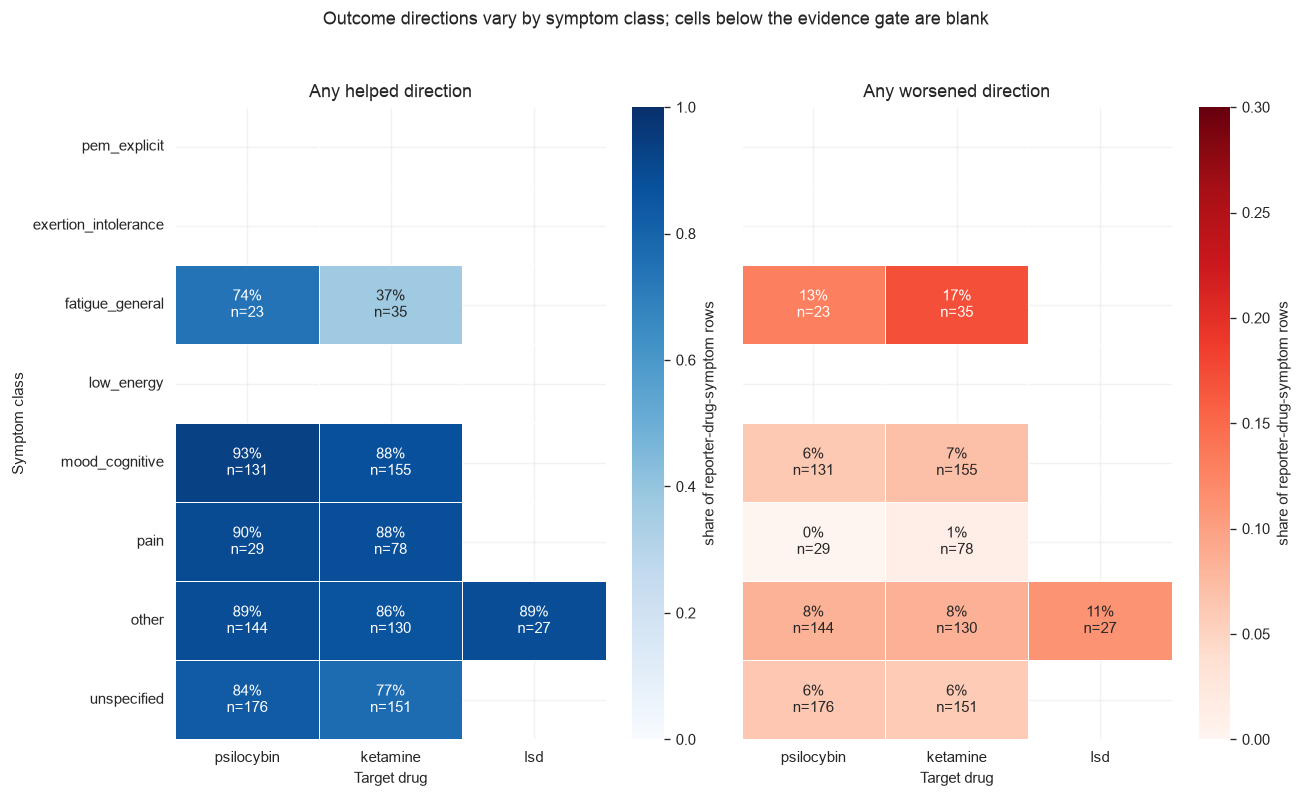

In [9]:
def heat_frames(direction):
    sub = symptom_stats.query("direction == @direction")
    rate = sub.pivot(index="symptom class", columns="drug", values="rate").reindex(SYMPTOMS, axis=0).reindex(DRUGS, axis=1)
    rows = sub.pivot(index="symptom class", columns="drug", values="rows").reindex(SYMPTOMS, axis=0).reindex(DRUGS, axis=1)
    gate = sub.pivot(index="symptom class", columns="drug", values="evidence").reindex(SYMPTOMS, axis=0).reindex(DRUGS, axis=1)
    labels = rate.copy().astype(object)
    for i in rate.index:
        for j in rate.columns:
            if gate.loc[i, j] == "ok":
                labels.loc[i, j] = f"{rate.loc[i, j]:.0%}\nn={int(rows.loc[i, j])}"
            else:
                labels.loc[i, j] = f"n={int(rows.loc[i, j])}\ninsuff."
    return rate.mask(gate.ne("ok")), labels.to_numpy()


fig, axes = plt.subplots(1, 2, figsize=(11, 6.4), sharey=True)
for ax, direction, title, cmap in [
    (axes[0], "helped", "Any helped direction", "Blues"),
    (axes[1], "worsened", "Any worsened direction", "Reds"),
]:
    data, labels = heat_frames(direction)
    sns.heatmap(data, annot=labels, fmt="", cmap=cmap, vmin=0,
                vmax=1 if direction == "helped" else 0.3, linewidths=0.5,
                annot_kws={"fontsize": 9},
                cbar_kws={"label": "share of reporter-drug-symptom rows"}, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Target drug")
    ax.set_ylabel("Symptom class" if ax is axes[0] else "")
fig.suptitle("Outcome directions vary by symptom class; cells below the evidence gate are blank",
             y=1.03)
fig.tight_layout()
display(fig)
plt.close(fig)

In [10]:
# One factor at a time. An earlier draft compared each drug-symptom cell against
# every other cell in the corpus, so drug, symptom class, indication, route,
# access pattern and reporter mix all moved together and the difference could
# not be attributed to the symptom class. Each contrast below moves exactly one:
#   within drug    — one symptom class against the same drug's other classes
#   within symptom — one drug against the other drugs inside the same class
contrast_rows = []
for (drug, symptom), _ in symptom_pair.groupby(["drug", "symptom_class"], sort=False):
    same_drug = symptom_pair["drug"].eq(drug)
    same_symptom = symptom_pair["symptom_class"].eq(symptom)
    for kind, universe, focal in (
        ("within drug", same_drug, same_symptom),
        ("within symptom", same_symptom, same_drug),
    ):
        arm = symptom_pair[universe]
        for direction in ["helped", "worsened"]:
            result = clustered_difference(arm, direction, focal[universe],
                                          seed=seed_for(kind, drug, symptom, direction))
            if not result:
                continue
            contrast_rows.append({
                "comparison": kind, "drug": drug, "symptom class": symptom,
                "direction": direction, **result,
                "evidence": "ok" if meets_gate(result["focal rows"], result["focal patients"])
                            else "insufficient",
                "interval": interval_note(result["diff low"], result["diff high"]),
                # A cell where every row or no row carries the indicator has no
                # within-cell variation left to resample, so its interval is set
                # entirely by the comparison arm and is not a real uncertainty range.
                "boundary": result["rate (focal)"] in (0.0, 1.0),
            })
contrasts = pd.DataFrame(contrast_rows)
contrasts["|difference|"] = contrasts["difference (pp)"].abs()
contrasts["note"] = np.where(contrasts["boundary"],
                             "boundary rate — interval unreliable", "")
within_drug = contrasts.query("comparison == 'within drug'")
within_symptom = contrasts.query("comparison == 'within symptom'")

SHOW = ["drug", "symptom class", "direction", "focal rows", "focal patients",
        "rate (focal)", "rate (reference)", "reference rows", "difference (pp)",
        "diff low", "diff high", "Cohen h", "interval", "note"]
FMT = {"rate (focal)": "{:.1%}", "rate (reference)": "{:.1%}",
       "difference (pp)": "{:+.1f}", "diff low": "{:+.1f}", "diff high": "{:+.1f}",
       "Cohen h": "{:+.2f}"}
for frame, caption in (
    (within_drug, "Within drug: symptom class vs the same drug's other symptom classes "
                  "(drug, indication and access pattern held fixed)."),
    (within_symptom, "Within symptom class: drug vs the other drugs in the same class "
                     "(symptom class held fixed)."),
):
    display(
        frame.query("evidence == 'ok'")
        .sort_values("difference (pp)")[SHOW]
        .style.format(FMT).hide(axis="index").set_caption(caption)
    )

drug,symptom class,direction,focal rows,focal patients,rate (focal),rate (reference),reference rows,difference (pp),diff low,diff high,Cohen h,interval,note
ketamine,fatigue_general,helped,35,35,37.1%,83.5%,541,-46.4,-60.4,-30.1,-1.00,interval below 0,
psilocybin,fatigue_general,helped,23,23,73.9%,87.2%,507,-13.3,-33.3,+4.2,-0.34,interval spans 0,
psilocybin,pain,worsened,29,29,0.0%,7.6%,501,-7.6,-10.4,-5.1,-0.56,interval below 0,boundary rate — interval unreliable
ketamine,pain,worsened,78,78,1.3%,7.6%,498,-6.3,-9.4,-3.3,-0.33,interval below 0,
ketamine,unspecified,helped,151,151,76.8%,82.1%,425,-5.3,-12.8,+2.3,-0.13,interval spans 0,
psilocybin,unspecified,helped,176,176,83.5%,88.1%,354,-4.6,-11.1,+1.4,-0.13,interval spans 0,
psilocybin,mood_cognitive,worsened,131,131,6.1%,7.5%,399,-1.4,-6.3,+3.5,-0.06,interval spans 0,
psilocybin,unspecified,worsened,176,176,6.2%,7.6%,354,-1.4,-5.4,+2.6,-0.05,interval spans 0,
ketamine,unspecified,worsened,151,151,6.0%,7.1%,425,-1.1,-5.7,+3.7,-0.04,interval spans 0,
ketamine,mood_cognitive,worsened,155,155,7.1%,6.7%,421,+0.4,-3.4,+4.7,+0.02,interval spans 0,


drug,symptom class,direction,focal rows,focal patients,rate (focal),rate (reference),reference rows,difference (pp),diff low,diff high,Cohen h,interval,note
ketamine,fatigue_general,helped,35,35,37.1%,71.9%,32,-34.7,-57.6,-11.5,-0.71,interval below 0,
ketamine,unspecified,helped,151,151,76.8%,83.0%,194,-6.2,-14.1,+1.5,-0.15,interval spans 0,
ketamine,mood_cognitive,helped,155,155,87.7%,93.8%,146,-6.1,-12.2,+0.3,-0.21,interval spans 0,
ketamine,other,helped,130,130,86.2%,88.9%,171,-2.7,-10.0,+4.7,-0.08,interval spans 0,
psilocybin,pain,worsened,29,29,0.0%,2.4%,82,-2.4,-6.2,+0.0,-0.31,interval spans 0,boundary rate — interval unreliable
ketamine,pain,worsened,78,78,1.3%,3.0%,33,-1.7,-9.1,+3.7,-0.12,interval spans 0,
ketamine,unspecified,worsened,151,151,6.0%,6.7%,194,-0.7,-6.2,+4.8,-0.03,interval spans 0,
psilocybin,fatigue_general,worsened,23,23,13.0%,13.6%,44,-0.6,-16.9,+16.9,-0.02,interval spans 0,
psilocybin,other,worsened,144,144,8.3%,8.9%,157,-0.6,-6.8,+6.2,-0.02,interval spans 0,
psilocybin,mood_cognitive,worsened,131,131,6.1%,6.5%,170,-0.4,-6.0,+5.2,-0.01,interval spans 0,


In [11]:
helped_gated = symptom_stats.query("direction == 'helped' and evidence == 'ok'")
best = helped_gated.sort_values("rate", ascending=False).iloc[0]
worst = helped_gated.sort_values("rate").iloc[0]
excluded = symptom_stats.query("direction == 'helped' and evidence == 'insufficient'")

lead = (within_drug.query("direction == 'helped' and evidence == 'ok' and not boundary")
        .sort_values("|difference|", ascending=False).iloc[0])


def cell_rows(frame, drug, symptom, direction="helped"):
    """The rows of `frame` describing one drug-symptom cell."""
    return frame[frame["drug"].eq(drug) & frame["symptom class"].eq(symptom)
                 & frame["direction"].eq(direction)]


cross = cell_rows(within_symptom, lead["drug"], lead["symptom class"])
pem_cells = symptom_stats[symptom_stats["direction"].eq("helped")
                          & symptom_stats["symptom class"].eq("pem_explicit")]

agreement = ""
if not cross.empty:
    c = cross.iloc[0]
    agreement = (
        f" Holding the symptom class fixed instead and moving the drug points the same way: "
        f"{c['drug']} runs {abs(c['difference (pp)']):.1f} pp "
        f"{'above' if c['difference (pp)'] > 0 else 'below'} the other drugs inside "
        f"{c['symptom class']} ({c['diff low']:+.1f} to {c['diff high']:+.1f} pp, "
        f"{int(c['reference rows'])} reference rows). Two contrasts that move different "
        f"factors agreeing in sign is worth more than either alone."
    )

display(HTML(
    f"<p><strong>Plain-language verdict.</strong> Among drug-symptom cells that clear the "
    f"evidence gate, helped-reporting is highest for <strong>{best['drug']} / "
    f"{best['symptom class']}</strong> at {best['rate']:.1%} "
    f"({best['ci low']:.1%}–{best['ci high']:.1%}, n={int(best['rows'])}) and lowest for "
    f"<strong>{worst['drug']} / {worst['symptom class']}</strong> at {worst['rate']:.1%} "
    f"({worst['ci low']:.1%}–{worst['ci high']:.1%}, n={int(worst['rows'])}). The largest "
    f"one-factor deviation is <strong>{lead['drug']} / {lead['symptom class']}</strong>: "
    f"holding the drug fixed, helped-reporting in that symptom class runs "
    f"<strong>{abs(lead['difference (pp)']):.1f} percentage points "
    f"{'above' if lead['difference (pp)'] > 0 else 'below'}</strong> the same drug's other "
    f"symptom classes ({lead['diff low']:+.1f} to {lead['diff high']:+.1f} pp, Cohen "
    f"h={lead['Cohen h']:+.2f}).{agreement} Note the sign: this is a deficit in reported "
    f"benefit, not a benefit.</p>"
    f"<p><strong>And it is not a PEM result.</strong> Every explicit-PEM cell falls below the "
    f"evidence gate — the largest holds {int(pem_cells['rows'].max())} rows from "
    f"{int(pem_cells['patients'].max())} reporter accounts — so no post-exertional-malaise "
    f"estimate is reported for any drug. The deficit above is in <em>nonspecific fatigue</em>. "
    f"The earlier composite class merged the two and reported the result as PEM.</p>"
    f"<p>{len(excluded)} of {len(excluded) + len(helped_gated)} cells fall below the gate and "
    f"are excluded from these headlines, including every LSD cell outside <code>other</code>, "
    f"whose apparent extremes on a handful of rows are artefacts of cell size. These are "
    f"reporting shares, not probabilities that a drug will work or cause harm for a patient, "
    f"and no hypothesis test is implied by any interval above.</p>"
))

In [12]:
### 3.2 Drug, symptom, and their interaction in one model
# The two contrasts above each hold one factor fixed. This estimates both at once,
# with the drug-by-symptom interaction that says whether a symptom class behaves
# differently under one drug than another. Reporter accounts are the GEE cluster,
# so an account spanning several symptom classes is one unit. Restricted to gated
# cells, and to drugs with more than one gated cell — LSD has a single gated cell
# and can carry no interaction, so including it only produces degenerate terms.
import statsmodels.api as sm
import statsmodels.formula.api as smf

gated_cells = {(r["drug"], r["symptom class"])
               for _, r in symptom_stats.query("direction == 'helped'").iterrows()
               if r["evidence"] == "ok"}
model_drugs = [d for d in DRUGS if sum(dr == d for dr, _ in gated_cells) > 1]
model_rows = symptom_pair[
    [(d, s) in gated_cells and d in model_drugs
     for d, s in zip(symptom_pair["drug"], symptom_pair["symptom_class"])]
].copy()
model_rows["helped_int"] = model_rows["helped"].astype(int)
model_rows["sym"] = pd.Categorical(
    model_rows["symptom_class"],
    ["mood_cognitive"] + sorted(set(model_rows["symptom_class"]) - {"mood_cognitive"}))
model_rows["drg"] = pd.Categorical(
    model_rows["drug"], ["psilocybin"] + sorted(set(model_rows["drug"]) - {"psilocybin"}))

gee = smf.gee("helped_int ~ C(drg) * C(sym)", groups="patient",
              data=model_rows.sort_values("patient"),
              family=sm.families.Binomial(),
              cov_struct=sm.cov_struct.Exchangeable()).fit()
ci = gee.conf_int()
def readable(term):
    """`C(drg)[T.ketamine]:C(sym)[T.fatigue_general]` -> `ketamine x fatigue_general`."""
    for noise, plain in (("C(drg)[T.", ""), ("C(sym)[T.", ""), ("]", ""), (":", " x ")):
        term = term.replace(noise, plain)
    return term


model_table = pd.DataFrame({
    "term": [readable(t) for t in gee.params.index],
    "log-odds": gee.params.to_numpy(),
    "95% low": ci[0].to_numpy(),
    "95% high": ci[1].to_numpy(),
})
display(model_table.style.format({"log-odds": "{:+.2f}", "95% low": "{:+.2f}",
                                  "95% high": "{:+.2f}"}).hide(axis="index").set_caption(
    f"GEE logistic model of helped-reporting, {len(model_rows):,} rows from "
    f"{model_rows['patient'].nunique():,} reporter accounts; reference cell = psilocybin / "
    f"mood_cognitive. Coefficients are log-odds, not probabilities, and no p-value is read."))

inter = [t for t in gee.params.index if ":" in t and "fatigue_general" in t]
if inter:
    term = inter[0]
    display(HTML(
        f"<p><strong>Interaction.</strong> The general-fatigue main effect is "
        f"{gee.params['C(sym)[T.fatigue_general]']:+.2f} log-odds "
        f"({ci.loc['C(sym)[T.fatigue_general]', 0]:+.2f} to "
        f"{ci.loc['C(sym)[T.fatigue_general]', 1]:+.2f}): across these drugs, general fatigue "
        f"attracts less helped-reporting than mood/cognitive. The ketamine-by-general-fatigue "
        f"interaction adds {gee.params[term]:+.2f} ({ci.loc[term, 0]:+.2f} to "
        f"{ci.loc[term, 1]:+.2f}) on top of that — pointing the same way as the within-symptom "
        f"contrast, but with an interval that includes zero. The model therefore supports "
        f"'general fatigue attracts less reported benefit' more strongly than it supports "
        f"'ketamine specifically'.</p>"
    ))

term,log-odds,95% low,95% high
Intercept,+2.47,+1.88,+3.07
ketamine,-0.58,-1.32,+0.16
fatigue_general,-1.50,-2.53,-0.46
other,-0.43,-1.09,+0.23
pain,-0.44,-1.59,+0.71
unspecified,-0.74,-1.43,-0.05
ketamine x fatigue_general,-1.07,-2.38,+0.24
ketamine x other,+0.27,-0.60,+1.14
ketamine x pain,+0.40,-0.89,+1.69
ketamine x unspecified,+0.03,-0.84,+0.90


In [13]:
### 3.3 The same contrast under multilabel assignment
# Sensitivity for the precedence rule: here a record enters every symptom class
# it matches, so a "brain fog and fatigue" target counts in both. Cells overlap
# by construction, which is why this is a check on the primary analysis and not
# the primary analysis itself.
multilabel_effects = pd.concat(
    [effects[effects[f"sx_{name}"]].assign(symptom_class=name) for name in P.SYMPTOM_CLASSES
     if f"sx_{name}" in effects]
    + [effects[effects["symptom_class"].eq(name)] for name in ("other", "unspecified")]
)
multilabel_pair = multilabel_effects.groupby(["patient", "drug", "symptom_class"]).agg(
    helped=("direction", lambda s: (s == "helped").any()),
    worsened=("direction", lambda s: (s == "worsened").any()),
).reset_index()

multilabel_rows = []
for (drug, symptom), _ in multilabel_pair.groupby(["drug", "symptom_class"], sort=False):
    arm = multilabel_pair[multilabel_pair["drug"].eq(drug)]
    result = clustered_difference(arm, "helped", arm["symptom_class"].eq(symptom),
                                  seed=seed_for("multilabel", drug, symptom, "helped"))
    if result and meets_gate(result["focal rows"], result["focal patients"]):
        multilabel_rows.append({"drug": drug, "symptom class": symptom, **result})
multilabel_contrasts = pd.DataFrame(multilabel_rows)

primary = within_drug.query("direction == 'helped' and evidence == 'ok'")[
    ["drug", "symptom class", "difference (pp)", "diff low", "diff high", "focal rows"]]
comparison = primary.merge(
    multilabel_contrasts[["drug", "symptom class", "difference (pp)", "diff low",
                          "diff high", "focal rows"]],
    on=["drug", "symptom class"], how="outer", suffixes=(" (exclusive)", " (multilabel)"),
).sort_values("difference (pp) (exclusive)")
display(comparison.style.format(
    {c: "{:+.1f}" for c in comparison.columns if "difference" in c or "diff" in c}
    | {c: "{:,.0f}" for c in comparison.columns if "rows" in c},
    na_rep="below gate").hide(axis="index").set_caption(
    "Within-drug helped-reporting contrast, exclusive display label vs multilabel membership."))

if not multilabel_contrasts.empty:
    lead_multi = multilabel_contrasts.sort_values("difference (pp)").iloc[0]
    display(HTML(
        f"<p><strong>Sensitivity.</strong> Multilabel assignment moves rows into the classes "
        f"the precedence rule had taken them out of, which enlarges the fatigue and low-energy "
        f"cells and shrinks nothing. The leading deficit is unchanged in sign and cell: "
        f"{lead_multi['drug']} / {lead_multi['symptom class']} at "
        f"{lead_multi['difference (pp)']:+.1f} pp ({lead_multi['diff low']:+.1f} to "
        f"{lead_multi['diff high']:+.1f}, {int(lead_multi['focal rows'])} rows), against "
        f"{primary.sort_values('difference (pp)').iloc[0]['difference (pp)']:+.1f} pp under the "
        f"exclusive label. The attenuation is what dilution by less-affected records looks "
        f"like; the direction does not depend on the labelling rule.</p>"
    ))

drug,symptom class,difference (pp) (exclusive),diff low (exclusive),diff high (exclusive),focal rows (exclusive),difference (pp) (multilabel),diff low (multilabel),diff high (multilabel),focal rows (multilabel)
ketamine,fatigue_general,-46.4,-60.4,-30.1,35,-38.1,-52.2,-23.5,44
psilocybin,fatigue_general,-13.3,-33.3,+4.2,23,-8.1,-23.0,+6.2,29
ketamine,unspecified,-5.3,-12.8,+2.3,151,-5.3,-13.1,+2.6,151
psilocybin,unspecified,-4.6,-11.1,+1.4,176,-5.1,-11.2,+1.0,176
psilocybin,other,+3.1,-2.5,+8.8,144,+2.6,-3.2,+8.0,144
psilocybin,pain,+3.2,-9.6,+13.6,29,+2.9,-10.5,+13.2,29
lsd,other,+5.9,-11.7,+21.8,27,+5.3,-11.6,+20.7,27
ketamine,other,+7.0,+0.5,+13.3,130,+6.8,+0.3,+13.4,130
psilocybin,mood_cognitive,+8.7,+3.0,+14.3,131,+8.3,+2.8,+13.5,133
ketamine,pain,+8.9,+1.2,+16.7,78,+8.8,+1.2,+15.7,78


## 4. Within-person heterogeneity

Flattening all effects into one positive label would hide clinically relevant combinations.
Here a reporter-drug pair is **helped only**, **no-effect only**, **worsened only**, or
**mixed/conflicting** when it contains more than one direction or a mixed direction. The
profile is descriptive and mutually exclusive; the underlying symptom directions can still
span more than one symptom class.

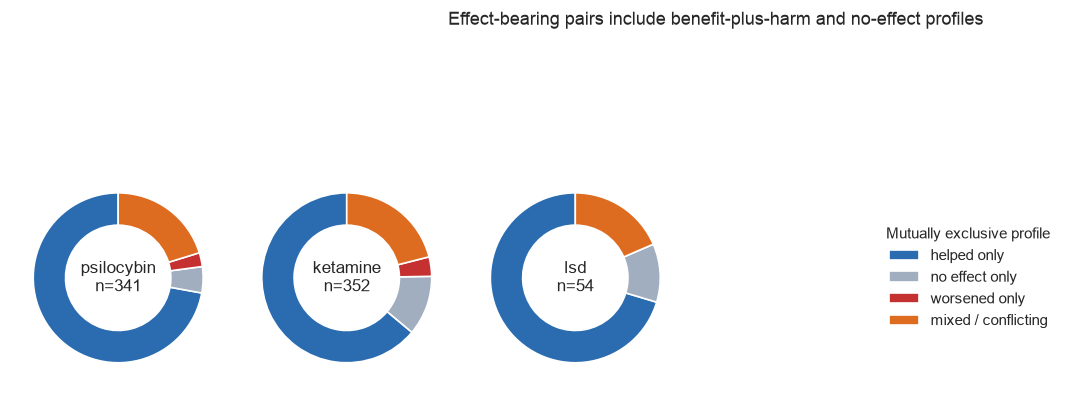

In [14]:
effect_pair = effects.groupby(["patient", "drug"]).agg(
    helped=("direction", lambda s: (s == "helped").any()),
    no_effect=("direction", lambda s: (s == "no_effect").any()),
    worsened=("direction", lambda s: (s == "worsened").any()),
    mixed=("direction", lambda s: (s == "mixed").any()),
    n_effect_records=("direction", "size"),
    n_directions=("direction", "nunique"),
    n_symptom_classes=("symptom_class", "nunique"),
).reset_index()
effect_pair["profile"] = effect_pair.apply(direction_profile, axis=1)
profile_order = ["helped only", "no effect only", "worsened only", "mixed / conflicting"]
profile_counts = pd.crosstab(effect_pair["drug"], effect_pair["profile"]).reindex(
    index=DRUGS, columns=profile_order, fill_value=0
)
profile_shares = profile_counts.div(profile_counts.sum(axis=1), axis=0)
fig, axes = plt.subplots(1, 3, figsize=(12, 4), subplot_kw={"aspect": "equal"})
colors = ["#2b6cb0", "#a0aec0", "#c53030", "#dd6b20"]
for ax, drug in zip(axes, DRUGS):
    vals = profile_counts.loc[drug].to_numpy()
    ax.pie(vals, labels=None, colors=colors, startangle=90,
           wedgeprops={"width": 0.38, "edgecolor": "white"})
    ax.text(0, 0, f"{drug}\nn={int(vals.sum())}", ha="center", va="center", fontsize=10)
axes[-1].legend(profile_order, title="Mutually exclusive profile", bbox_to_anchor=(1.9, 0.5),
                loc="center left", frameon=False)
fig.suptitle("Effect-bearing pairs include benefit-plus-harm and no-effect profiles", y=1.02)
fig.tight_layout(rect=[0, 0, 0.82, 1])
display(fig)
plt.close(fig)


In [15]:
profile_table = profile_counts.copy()
profile_table["effect-bearing pairs"] = profile_table.sum(axis=1)
profile_table["benefit + worsening pairs"] = (
    effect_pair.groupby("drug").apply(lambda x: int((x["helped"] & x["worsened"]).sum()),
                                      include_groups=False).reindex(DRUGS).to_numpy()
)
profile_table["mean symptom classes"] = (
    effect_pair.groupby("drug")["n_symptom_classes"].mean().reindex(DRUGS).to_numpy()
)
display(profile_table.style.format({"mean symptom classes": "{:.2f}"}))

# Cross-drug comparison of the mixed/conflicting share, as differences with
# clustered intervals rather than a chi-squared statistic on clustered rows.
effect_pair["mixed_conflicting"] = effect_pair["profile"].eq("mixed / conflicting")
profile_rows = []
for drug in DRUGS:
    sub = effect_pair[effect_pair["drug"].eq(drug)]
    rate, lo, hi = clustered_rate(sub, "mixed_conflicting", seed=seed_for("profile", drug))
    result = clustered_difference(effect_pair, "mixed_conflicting",
                                  effect_pair["drug"].eq(drug),
                                  seed=seed_for("profile-diff", drug))
    profile_rows.append({
        "drug": drug, "pairs": len(sub), "mixed / conflicting": rate,
        "95% clustered CI": f"{lo:.1%}–{hi:.1%}",
        "difference vs other drugs (pp)": result["difference (pp)"],
        "diff low": result["diff low"], "diff high": result["diff high"],
        "interval": interval_note(result["diff low"], result["diff high"]),
        "evidence": "ok" if meets_gate(len(sub), sub["patient"].nunique()) else "insufficient",
    })
profile_contrast = pd.DataFrame(profile_rows)
display(profile_contrast.style.format({
    "mixed / conflicting": "{:.1%}", "difference vs other drugs (pp)": "{:+.1f}",
    "diff low": "{:+.1f}", "diff high": "{:+.1f}",
}).hide(axis="index"))

mixed_total = int((effect_pair["helped"] & effect_pair["worsened"]).sum())
spans = profile_contrast["interval"].eq("interval spans 0").all()
display(HTML(
    f"<p><strong>Comparison.</strong> The mixed/conflicting share is "
    + ", ".join(f"{r['drug']} {r['mixed / conflicting']:.1%} (n={int(r['pairs'])})"
                for _, r in profile_contrast.iterrows())
    + ". Every cross-drug difference interval "
    + ("spans zero, so this comparison does not resolve a difference in profile distributions "
           "at this sample size — which is not the same as showing there is none"
       if spans else "is listed above with its sign")
    + f"; LSD has the smallest denominator and is the least stable. <strong>Plain language:</strong> "
    f"{mixed_total} of {len(effect_pair)} effect-bearing pairs contain both at least one helped "
    f"and one worsened direction. Those benefit-plus-harm reports are a substantive outcome, "
    f"not noise to be collapsed into 'positive'.</p>"
))

profile,helped only,no effect only,worsened only,mixed / conflicting,effect-bearing pairs,benefit + worsening pairs,mean symptom classes
drug,,,,,,,
psilocybin,246,17,9,69,341,18,1.55
ketamine,225,40,13,74,352,13,1.64
lsd,38,6,0,10,54,4,1.48


drug,pairs,mixed / conflicting,95% clustered CI,difference vs other drugs (pp),diff low,diff high,interval,evidence
psilocybin,341,20.2%,16.1%–24.6%,-0.5,-6.4,+5.5,interval spans 0,ok
ketamine,352,21.0%,17.0%–25.3%,+1.0,-4.6,+6.6,interval spans 0,ok
lsd,54,18.5%,9.3%–29.6%,-2.1,-12.0,+9.5,interval spans 0,ok


## 5. Adverse-event profile and co-occurrence

An adverse-event row is an extracted reported event. The pair-level outcomes below count any
event, at least one severe event, an event marked ongoing at report, and more than one event.
Missing severity remains its own category. These measures describe reporting patterns and
cannot estimate incidence, attributable risk, or whether the drug caused the event.

One relationship is deliberately **not** presented as a finding. An adverse-event record and a
`worsened` effect direction are frequently extracted from the same passage, and sometimes from
the same claim, so "pairs reporting adverse category X are more likely to report worsening" is
close to a restatement of the input rather than a discovery about the drug. An earlier draft of
this notebook ranked nine such pairings as its leading results; §9 now excludes that scan and
explains why. The co-occurrence table below is retained only as a description of how benefit and
harm reports overlap within a pair.

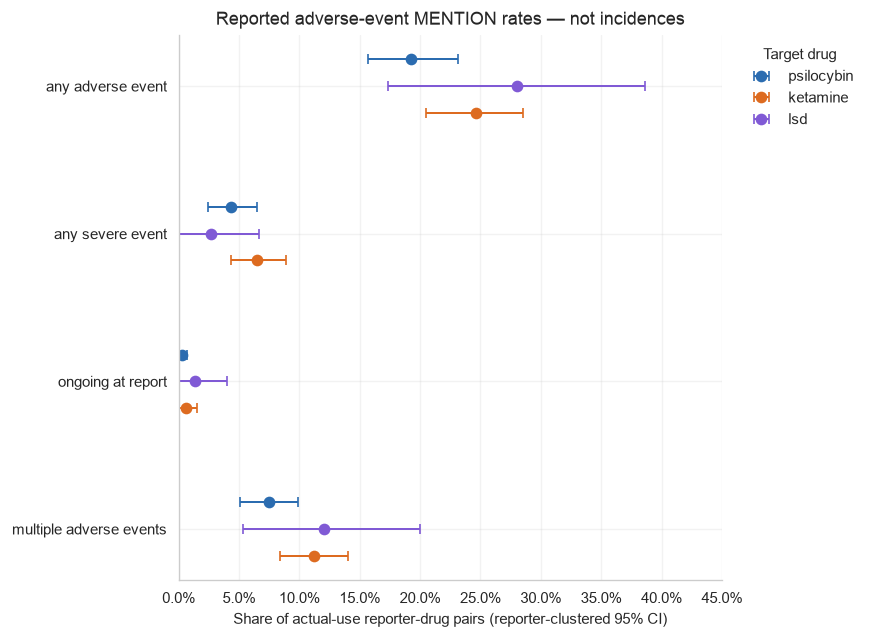

In [16]:
ae_pair = adverse.groupby(["patient", "drug"]).agg(
    n_adverse_events=("category", "size"),
    any_severe=("severity", lambda s: s.eq("severe").any()),
    any_ongoing=("duration_bin", lambda s: s.eq("ongoing_at_report").any()),
    n_categories=("category", "nunique"),
).reset_index()
ae_pair["any_adverse_event"] = True
ae_pair["multiple_events"] = ae_pair["n_adverse_events"] > 1
ae_flags = actual_pairs.merge(ae_pair, on=["patient", "drug"], how="left")
for col in ["n_adverse_events", "n_categories"]:
    ae_flags[col] = ae_flags[col].fillna(0).astype(int)
for col in ["any_adverse_event", "any_severe", "any_ongoing", "multiple_events"]:
    ae_flags[col] = ae_flags[col].fillna(False).astype(bool)

ae_metric_labels = {
    "any_adverse_event": "any adverse event",
    "any_severe": "any severe event",
    "any_ongoing": "ongoing at report",
    "multiple_events": "multiple adverse events",
}
ae_rows = []
for drug in DRUGS:
    sub = ae_flags[ae_flags["drug"].eq(drug)]
    for metric, label in ae_metric_labels.items():
        rate, lo, hi = clustered_rate(sub, metric, seed=seed_for("aerate", drug, metric))
        ae_rows.append({
            "drug": drug, "metric": label, "indicator": metric,
            "k": int(sub[metric].sum()), "n": len(sub), "rate": rate,
            "ci low": lo, "ci high": hi,
        })
ae_metrics = pd.DataFrame(ae_rows)

fig, ax = plt.subplots(figsize=(9, 5.4))
metric_order = list(ae_metric_labels.values())
y_base = np.arange(len(metric_order))[::-1]
offsets = {"ketamine": -0.18, "lsd": 0.0, "psilocybin": 0.18}
for drug in DRUGS:
    sub = ae_metrics[ae_metrics["drug"].eq(drug)].set_index("metric").reindex(metric_order)
    y = y_base + offsets[drug]
    x = sub["rate"].to_numpy()
    xerr = np.vstack([x - sub["ci low"].to_numpy(), sub["ci high"].to_numpy() - x])
    ax.errorbar(x, y, xerr=xerr, fmt="o", capsize=3, lw=1.2, color=DRUG_COLORS[drug], label=drug)
ax.set_yticks(y_base, metric_order)
ax.set_xlim(0, max(0.45, float(ae_metrics["ci high"].max()) + 0.03))
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
ax.set_xlabel("Share of actual-use reporter-drug pairs (reporter-clustered 95% CI)")
ax.set_title("Reported adverse-event MENTION rates — not incidences")
ax.legend(title="Target drug", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
fig.tight_layout(rect=[0, 0, 0.82, 1])
display(fig)
plt.close(fig)

In [17]:
ae_display = ae_metrics[["drug", "metric", "k", "n", "rate", "ci low", "ci high"]].copy()
ae_display["rate"] = ae_display["rate"].map("{:.1%}".format)
ae_display["clustered 95% CI"] = [
    f"{lo:.1%}–{hi:.1%}" if pd.notna(lo) else "—"
    for lo, hi in zip(ae_metrics["ci low"], ae_metrics["ci high"])
]
display(ae_display[["drug", "metric", "k", "n", "rate", "clustered 95% CI"]]
        .style.hide(axis="index"))

# Cross-drug adverse-event comparisons as differences with clustered intervals.
ae_contrast_rows = []
for metric, label in ae_metric_labels.items():
    for drug in DRUGS:
        sub = ae_flags[ae_flags["drug"].eq(drug)]
        result = clustered_difference(ae_flags, metric, ae_flags["drug"].eq(drug),
                                      seed=seed_for("ae", metric, drug))
        if not result:
            continue
        ae_contrast_rows.append({
            "metric": label, "drug": drug,
            "rate (focal)": result["rate (focal)"], "rate (other drugs)": result["rate (reference)"],
            "focal pairs": result["focal rows"], "difference (pp)": result["difference (pp)"],
            "diff low": result["diff low"], "diff high": result["diff high"],
            "Cohen h": result["Cohen h"],
            "interval": interval_note(result["diff low"], result["diff high"]),
            "evidence": "ok" if meets_gate(result["focal rows"], result["focal patients"])
                        else "insufficient",
        })
ae_contrasts = pd.DataFrame(ae_contrast_rows)
display(ae_contrasts.style.format({
    "rate (focal)": "{:.1%}", "rate (other drugs)": "{:.1%}", "difference (pp)": "{:+.1f}",
    "diff low": "{:+.1f}", "diff high": "{:+.1f}", "Cohen h": "{:+.2f}",
}).hide(axis="index"))

separated = ae_contrasts.query("evidence == 'ok' and interval != 'interval spans 0'")
display(HTML(
    "<p><strong>Comparison.</strong> "
    + (f"{len(separated)} of {len(ae_contrasts.query('evidence == \"ok\"'))} gated drug-vs-rest "
       f"adverse-event differences have an interval clear of zero: "
       + "; ".join(f"{r['drug']} / {r['metric']} {r['difference (pp)']:+.1f} pp"
                   for _, r in separated.iterrows())
       if len(separated) else
       "no gated drug-vs-rest adverse-event difference has an interval clear of zero")
    + ". Any separation here is first of all a difference in reporting context — ketamine "
      "exposure in this cohort is largely IV/IM by stated route. This run records no "
      "administration-setting field, so nothing here establishes a supervision or clinic "
      "context — only a route difference. These are mention rates, never incidences.</p>"
))

drug,metric,k,n,rate,clustered 95% CI
psilocybin,any adverse event,80,415,19.3%,15.7%–23.1%
psilocybin,any severe event,18,415,4.3%,2.4%–6.5%
psilocybin,ongoing at report,1,415,0.2%,0.0%–0.7%
psilocybin,multiple adverse events,31,415,7.5%,5.1%–9.9%
ketamine,any adverse event,114,463,24.6%,20.5%–28.5%
ketamine,any severe event,30,463,6.5%,4.3%–8.9%
ketamine,ongoing at report,3,463,0.6%,0.0%–1.5%
ketamine,multiple adverse events,52,463,11.2%,8.4%–14.0%
lsd,any adverse event,21,75,28.0%,17.3%–38.7%
lsd,any severe event,2,75,2.7%,0.0%–6.7%


metric,drug,rate (focal),rate (other drugs),focal pairs,difference (pp),diff low,diff high,Cohen h,interval,evidence
any adverse event,psilocybin,19.3%,25.1%,415,-5.8,-11.0,-0.7,-0.14,interval below 0,ok
any adverse event,ketamine,24.6%,20.6%,463,+4.0,-1.0,+9.4,+0.10,interval spans 0,ok
any adverse event,lsd,28.0%,22.1%,75,+5.9,-4.1,+16.7,+0.14,interval spans 0,ok
any severe event,psilocybin,4.3%,5.9%,415,-1.6,-4.4,+1.2,-0.07,interval spans 0,ok
any severe event,ketamine,6.5%,4.1%,463,+2.4,-0.3,+5.1,+0.11,interval spans 0,ok
any severe event,lsd,2.7%,5.5%,75,-2.8,-6.3,+1.4,-0.14,interval spans 0,ok
ongoing at report,psilocybin,0.2%,0.7%,415,-0.5,-1.4,+0.3,-0.07,interval spans 0,ok
ongoing at report,ketamine,0.6%,0.4%,463,+0.2,-0.6,+1.1,+0.03,interval spans 0,ok
ongoing at report,lsd,1.3%,0.5%,75,+0.9,-0.8,+4.1,+0.10,interval spans 0,ok
multiple adverse events,psilocybin,7.5%,11.3%,415,-3.9,-7.4,-0.2,-0.13,interval below 0,ok


,ketamine / mild,ketamine / missing severity,ketamine / moderate,ketamine / severe,lsd / mild,lsd / missing severity,lsd / moderate,lsd / severe,psilocybin / mild,psilocybin / missing severity,psilocybin / moderate,psilocybin / severe
category,,,,,,,,,,,,
other,17,27,44,35,3,5,10,2,25,10,38,11
fatigue_pem_flare,17,6,27,7,1,2,5,1,7,2,20,15
anxiety_panic,3,0,11,4,0,0,1,0,6,0,7,7
nausea_gi,3,3,6,3,1,0,0,0,6,0,10,1
dissociation,7,1,5,3,0,0,0,0,0,0,1,0
cardiac,3,0,3,0,0,0,2,0,0,1,5,1
headache,1,1,0,2,1,0,1,0,5,0,3,1
insomnia,2,1,2,2,2,0,0,0,1,0,0,0
derealization,1,0,1,2,0,0,0,0,0,0,1,1


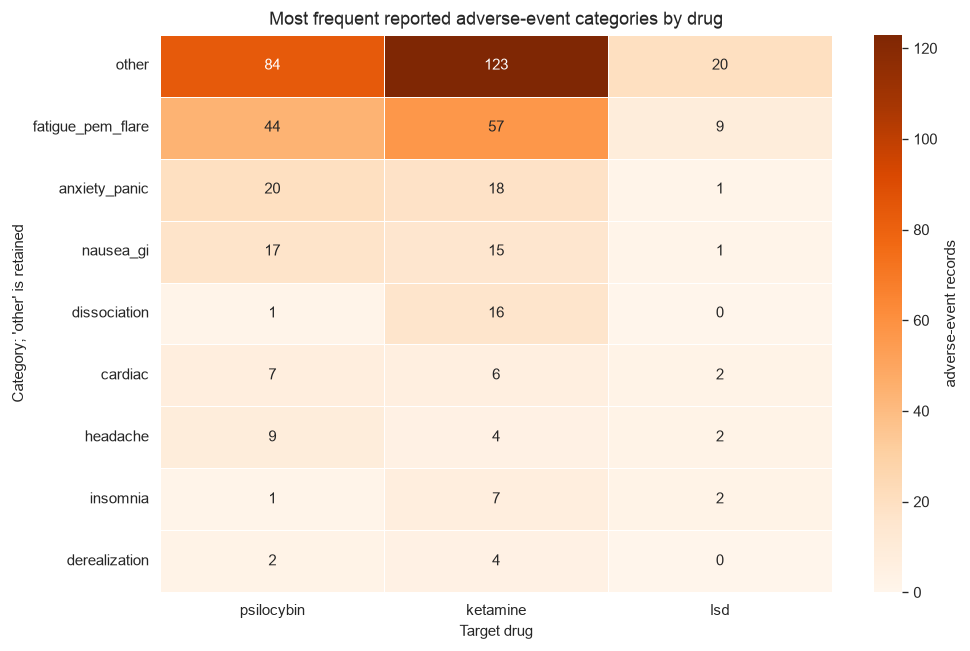

In [18]:
adverse["severity_display"] = adverse["severity"].fillna("missing severity")
ae_category_counts = pd.crosstab(adverse["category"], [adverse["drug"], adverse["severity_display"]])
ae_category_counts = ae_category_counts.reindex(
    index=ae_category_counts.sum(axis=1).sort_values(ascending=False).head(12).index
)
ae_category_counts.columns = [f"{drug} / {severity}" for drug, severity in ae_category_counts.columns]
display(ae_category_counts.style.format("{:.0f}").background_gradient(cmap="Oranges"))

category_drug = pd.crosstab(adverse["category"], adverse["drug"]).reindex(
    index=ae_category_counts.index, columns=DRUGS, fill_value=0
)
fig, ax = plt.subplots(figsize=(8.5, 5.5))
sns.heatmap(category_drug, annot=True, fmt="g", cmap="Oranges", linewidths=0.5,
            cbar_kws={"label": "adverse-event records"}, ax=ax)
ax.set_title("Most frequent reported adverse-event categories by drug")
ax.set_xlabel("Target drug")
ax.set_ylabel("Category; 'other' is retained")
fig.tight_layout()
display(fig)
plt.close(fig)


In [19]:
ae_effect = effect_pair.merge(
    ae_pair[["patient", "drug", "any_adverse_event", "any_severe", "any_ongoing"]],
    on=["patient", "drug"], how="left"
)
for col in ["any_adverse_event", "any_severe", "any_ongoing"]:
    ae_effect[col] = ae_effect[col].fillna(False).astype(bool)
co_rows = []
for drug in DRUGS:
    sub = ae_effect[ae_effect["drug"].eq(drug)]
    for outcome in ["helped", "worsened", "mixed_conflicting"]:
        den = int(sub[outcome].sum())
        num = int((sub[outcome] & sub["any_adverse_event"]).sum())
        co_rows.append({"drug": drug, "effect profile signal": outcome,
                        "AE-bearing pairs": num, "profile pairs": den,
                        "AE share within profile": num / den if den else np.nan,
                        "evidence": "ok" if den >= MIN_ROWS else "insufficient"})
cooccurrence = pd.DataFrame(co_rows)
display(cooccurrence.style.format({"AE share within profile": "{:.1%}"}, na_rep="—")
        .hide(axis="index"))
display(HTML(
    "<p><strong>Interpretation.</strong> This table describes how often a pair carrying a "
    "helped, worsened, or mixed/conflicting effect signal also carries an adverse-event record. "
    "It establishes no temporal order and no causation, and it is <em>not</em> evidence that "
    "harm follows from a direction label: a worsened direction and an adverse event are often "
    "extracted from the same sentence, so their overlap is partly an artefact of how the text "
    "was segmented. The reason to keep it visible is the opposite of a finding — a reported "
    "adverse event coexists with reported benefit often enough that collapsing a pair to "
    "'positive' would hide it.</p>"
))

drug,effect profile signal,AE-bearing pairs,profile pairs,AE share within profile,evidence
psilocybin,helped,60,304,19.7%,ok
psilocybin,worsened,26,32,81.2%,ok
psilocybin,mixed_conflicting,35,69,50.7%,ok
ketamine,helped,70,294,23.8%,ok
ketamine,worsened,27,30,90.0%,ok
ketamine,mixed_conflicting,35,74,47.3%,ok
lsd,helped,14,46,30.4%,ok
lsd,worsened,1,4,25.0%,insufficient
lsd,mixed_conflicting,4,10,40.0%,insufficient


## 6. Duration and persistence

Duration is a stated field on only a small fraction of extracted effects. The categories are
reported as acute/short-lived, intermediate, long-lasting, or ongoing at report. The **91%
unstated-duration limitation applies to every duration interpretation below**: the chart
describes the distribution among stated durations and does not show how long unreported
effects lasted.

drug,direction,symptom_class,duration class,effect records
psilocybin,helped,mood_cognitive,intermediate,19
ketamine,helped,unspecified,intermediate,18
psilocybin,helped,other,intermediate,17
psilocybin,helped,unspecified,acute / short-lived,14
ketamine,helped,unspecified,acute / short-lived,12
psilocybin,helped,unspecified,intermediate,11
psilocybin,helped,mood_cognitive,long-lasting,10
psilocybin,helped,mood_cognitive,ongoing at report,9
psilocybin,helped,mood_cognitive,acute / short-lived,9
ketamine,helped,unspecified,long-lasting,9


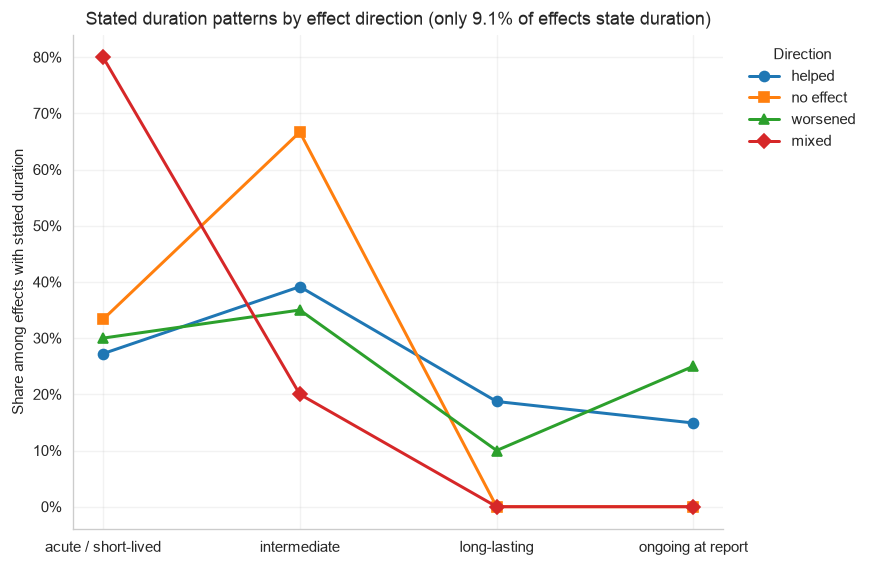

In [20]:
effects_with_duration = effects[effects["duration_bin"].notna()].copy()
effects_with_duration["duration class"] = effects_with_duration["duration_bin"].map(duration_labels)
duration_table = effects_with_duration.groupby(
    ["drug", "direction", "symptom_class", "duration class"], dropna=False
).size().rename("effect records").reset_index()
display(duration_table.sort_values("effect records", ascending=False).head(30).style.hide(axis="index"))

duration_class_order = ["acute / short-lived", "intermediate", "long-lasting", "ongoing at report"]
duration_direction = pd.crosstab(
    effects_with_duration["direction"], effects_with_duration["duration class"]
).reindex(index=DIRECTIONS, columns=duration_class_order, fill_value=0)
duration_share = duration_direction.div(duration_direction.sum(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(9, 4.8))
markers = ["o", "s", "^", "D"]
for direction, marker in zip(DIRECTIONS, markers):
    ax.plot(duration_class_order, duration_share.loc[direction], marker=marker,
            linewidth=1.8, label=direction.replace("_", " "))
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
ax.set_ylabel("Share among effects with stated duration")
ax.set_xlabel("")
ax.set_title("Stated duration patterns by effect direction (only 9.1% of effects state duration)")
ax.legend(title="Direction", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
fig.tight_layout(rect=[0, 0, 0.82, 1])
display(fig)
plt.close(fig)


In [21]:
duration_rows = []
for direction in DIRECTIONS:
    sub = effects_with_duration[effects_with_duration["direction"].eq(direction)]
    if sub.empty:
        continue
    for duration_class in duration_class_order:
        indicator = f"is_{duration_class}"
        sub = sub.assign(**{indicator: sub["duration class"].eq(duration_class)})
        rate, lo, hi = clustered_rate(sub, indicator, seed=seed_for("dur", direction, duration_class))
        duration_rows.append({
            "direction": direction, "duration class": duration_class,
            "records": int(sub[indicator].sum()), "records with duration": len(sub),
            "share": rate, "ci low": lo, "ci high": hi,
            "evidence": "ok" if meets_gate(len(sub), sub["patient"].nunique()) else "insufficient",
        })
duration_shares = pd.DataFrame(duration_rows)
display(duration_shares.style.format({
    "share": "{:.1%}", "ci low": "{:.1%}", "ci high": "{:.1%}",
}, na_rep="—").hide(axis="index"))

stated_pct = len(effects_with_duration) / len(effects) if len(effects) else np.nan
insufficient = duration_shares.query("evidence == 'insufficient'")["direction"].unique()
display(HTML(
    f"<p><strong>Comparison.</strong> Among the {len(effects_with_duration)} effect records that "
    f"state a duration, the class mix is tabulated above per direction with reporter-clustered "
    f"intervals. No test of association is reported: the rows are clustered inside reporter accounts and "
    f"the interesting quantity here is coverage, not a contingency statistic. "
    f"{'The ' + ', '.join(insufficient) + ' direction(s) fall below the evidence gate. ' if len(insufficient) else ''}"
    f"<strong>Plain language:</strong> this describes the {stated_pct:.1%} of effect records with "
    f"a duration field, not persistence. The remaining {1 - stated_pct:.1%} are unstated and "
    f"cannot be classified as short-lived, long-lasting, or ongoing — in particular, an "
    f"effect with no stated duration is not a short one.</p>"
))

direction,duration class,records,records with duration,share,ci low,ci high,evidence
helped,acute / short-lived,64,235,27.2%,20.5%,35.0%,ok
helped,intermediate,92,235,39.1%,30.9%,48.5%,ok
helped,long-lasting,44,235,18.7%,13.3%,24.6%,ok
helped,ongoing at report,35,235,14.9%,7.8%,22.0%,ok
no_effect,acute / short-lived,1,3,33.3%,0.0%,100.0%,insufficient
no_effect,intermediate,2,3,66.7%,0.0%,100.0%,insufficient
no_effect,long-lasting,0,3,0.0%,0.0%,0.0%,insufficient
no_effect,ongoing at report,0,3,0.0%,0.0%,0.0%,insufficient
worsened,acute / short-lived,6,20,30.0%,9.7%,58.8%,ok
worsened,intermediate,7,20,35.0%,15.8%,61.1%,ok


## 7. Dose and use-context coverage

Dose amounts are analyzed only inside compatible canonical units. Grams of psilocybin and
milligrams of ketamine are never pooled with each other or with count-based records.

**Route is reported for ketamine only, and route is not a setting.** Ketamine is the one arm
where the stated route varies at all: its records split between IV/IM and intranasal,
sublingual, and oral. Psilocybin is oral wherever a route is stated, so the field adds nothing,
and **no LSD dose record states a route at all**. Coverage for all three is still tabulated —
the asymmetry in what each community writes down is itself informative.

**This run measures no administration setting.** There is no structured supervision or
context field in the loaded data, and route does not stand in for one: intranasal esketamine is
routinely clinic-administered, and an injection label documents no supervision either. So no
group below is called clinic, supervised, self-administered, or take-home, and no difference
elsewhere in this notebook is explained by setting.

**LSD numeric dosing is reported as insufficient data.** The next cells quantify how thin it is
rather than binning it into a result.

drug,ketamine,lsd,psilocybin
field,,,
dose records,557,74,707
amount + unit,50,19,195
route stated,361,0,109
intent stated,85,43,394
formulation stated,104,5,141
schedule stated,170,14,157
context stated,258,5,59


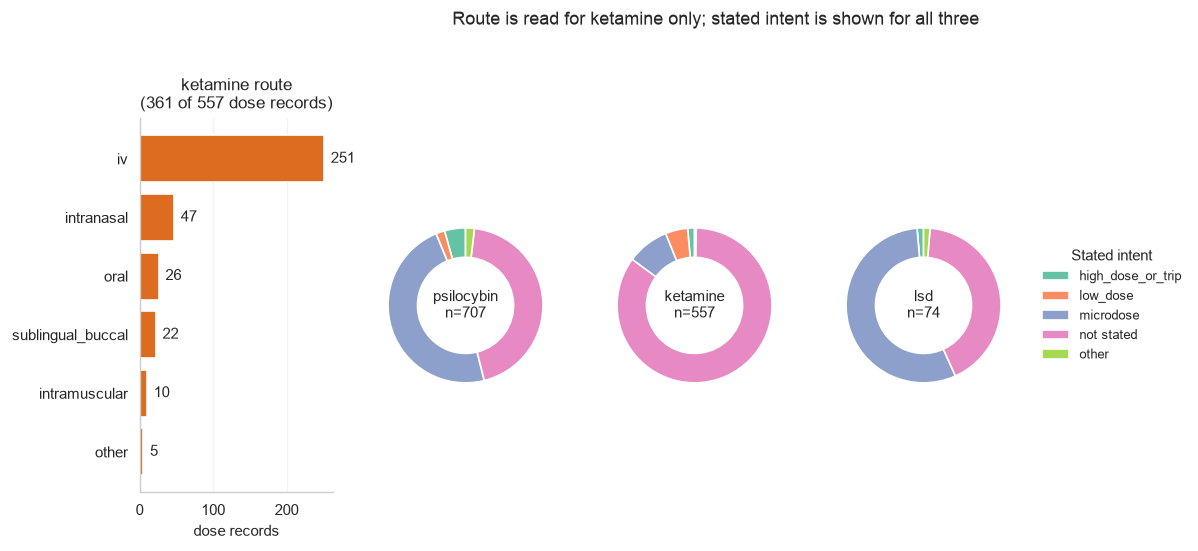

In [22]:
dose_context_rows = []
for drug in DRUGS:
    ds = doses[doses["drug"].eq(drug)]
    fields = {
        "dose records": len(ds),
        "amount + unit": int((ds["amount_lower"].notna() & ds["unit_canon"].notna()).sum()),
        "route stated": int(ds["route_canon"].notna().sum()),
        "intent stated": int(ds["intent_canon"].notna().sum()),
        "formulation stated": int(ds["has_formulation"].sum()),
        "schedule stated": int(ds["has_schedule"].sum()),
        "context stated": int(ds["has_context"].sum()),
    }
    for field, count in fields.items():
        dose_context_rows.append({"drug": drug, "field": field, "count": count})
dose_context = pd.DataFrame(dose_context_rows)
dose_context_pivot = dose_context.pivot(index="field", columns="drug", values="count").reindex(
    ["dose records", "amount + unit", "route stated", "intent stated",
     "formulation stated", "schedule stated", "context stated"]
)
display(dose_context_pivot.style.format("{:.0f}"))

# Route: ketamine only. Intent: all three, where microdosing vocabulary differs.
ket_route = (doses.loc[doses["drug"].eq(ROUTE_DRUG), "route_canon"].dropna()
             .value_counts().sort_values())
intent_counts = pd.crosstab(doses["drug"], doses["intent_canon"].fillna("not stated")).reindex(
    index=DRUGS, fill_value=0
)

fig = plt.figure(figsize=(12, 4.4))
ax_route = fig.add_subplot(1, 4, 1)
ax_route.barh(ket_route.index, ket_route.to_numpy(), color=DRUG_COLORS[ROUTE_DRUG])
for y, v in enumerate(ket_route.to_numpy()):
    ax_route.annotate(f"{v}", (v, y), xytext=(4, 0), textcoords="offset points",
                      va="center", fontsize=9)
ax_route.set_title(f"{ROUTE_DRUG} route\n({int(ket_route.sum())} of "
                   f"{int(doses['drug'].eq(ROUTE_DRUG).sum())} dose records)", fontsize=10)
ax_route.set_xlabel("dose records")
ax_route.grid(axis="y", visible=False)
for col, drug in enumerate(DRUGS):
    ax = fig.add_subplot(1, 4, col + 2, aspect="equal")
    vals = intent_counts.loc[drug]
    ax.pie(vals, labels=None, startangle=90, colors=sns.color_palette("Set2", len(vals)),
           wedgeprops={"width": 0.38, "edgecolor": "white"})
    ax.text(0, 0, f"{drug}\nn={int(vals.sum())}", ha="center", va="center", fontsize=9)
    if col == len(DRUGS) - 1:
        ax.legend(vals.index, title="Stated intent", bbox_to_anchor=(1.05, 0.5),
                  loc="center left", frameon=False, fontsize=8)
fig.suptitle("Route is read for ketamine only; stated intent is shown for all three", y=1.03)
fig.tight_layout(rect=[0, 0, 0.84, 1])
display(fig)
plt.close(fig)

In [23]:
# Ketamine route composition. Route is a *stated route*, not a setting: the
# probe records no supervision or administration-context field, so IV/IM is
# reported as a route group and nothing is inferred about where it happened.
INJECTED_ROUTES = {"iv", "intramuscular"}
ket_doses = doses[doses["drug"].eq(ROUTE_DRUG)].copy()
ket_stated = ket_doses[ket_doses["route_canon"].notna()].copy()
ket_stated["route group"] = np.where(ket_stated["route_canon"].isin(INJECTED_ROUTES),
                                     "IV/IM stated route", "other stated routes")
route_composition = (
    ket_stated.groupby(["route group", "route_canon"])
    .agg(records=("route_canon", "size"), reporters=("patient", "nunique"))
    .assign(**{"% of stated-route records":
               lambda d: 100 * d["records"] / len(ket_stated)})
    .sort_values("records", ascending=False)
)
display(route_composition.style.format({"% of stated-route records": "{:.1f}%"}))

group_share = ket_stated["route group"].value_counts(normalize=True)
context_coverage = ket_doses["has_context"].mean()
display(HTML(
    f"<p><strong>Interpretation.</strong> Of {len(ket_stated)} ketamine dose records that state "
    f"a route ({100 * len(ket_stated) / len(ket_doses):.0f}% of "
    f"{len(ket_doses)}), {group_share.get('IV/IM stated route', 0):.0%} state an IV or IM route "
    f"and {group_share.get('other stated routes', 0):.0%} state an intranasal, "
    f"sublingual/buccal, or oral route. <strong>Route is not a proxy for setting.</strong> "
    f"Intranasal esketamine is commonly given under supervision and an injection label does not "
    f"document supervision either, so neither group can be called clinic-administered or "
    f"self-administered. A treatment-context field exists on only "
    f"{context_coverage:.0%} of ketamine dose records and is not loaded as structured text, so "
    f"administration setting is <strong>unmeasured in this run</strong> and is not used to "
    f"explain any difference in this notebook. Route is not interpreted for psilocybin (oral "
    f"wherever stated) or LSD (never stated), and none of these distributions should be read as "
    f"representative prescribing or use patterns.</p>"
))

### Compatible-unit dose bins, where there are enough of them

Numeric amounts are lower bounds when the extractor stored a range. Bins are defined only inside
a drug/unit-compatible subset and are never pooled across units. They are retained as reporting
associations, described with clustered intervals and effect sizes — no test, no dose-response
language, no causal reading.

**Each dose is linked to outcomes from its own claim.** A claim is one extracted exposure event
and is the finest key the probe stores that a dose and an outcome are known to share. An earlier
version joined doses to outcomes on reporter and drug alone, which copied a reporter's entire
outcome summary onto every dose bin they had ever mentioned — so one reported benefit could count
as evidence for 1 g and 5 g at once. Two exclusions are applied before any outcome is read, and
both are counted in the audit below: a claim whose dose records straddle more than one bin is
ambiguous and is dropped whole, and a claim carrying no effect record has no outcome to link.

Coverage then decides which subsets are eligible at all. The next cell reports each candidate
subset against the evidence gate and states plainly where there is **insufficient data**, rather
than drawing a panel over a handful of records.

In [24]:
# Only drug/unit subsets with a real numeric vocabulary are candidates. LSD has
# neither: 11 microgram records from 9 reporters, plus 8 unitless "count"
# records that cannot be converted without inventing a per-unit strength.
DOSE_BINS = {
    ("psilocybin", "g"): ("psilocybin / g", [(1, "≤1 g"), (3, "1–3 g"), (np.inf, ">3 g")]),
    ("ketamine", "mg"): ("ketamine / mg", [(50, "≤50 mg"), (100, "51–100 mg"), (np.inf, ">100 mg")]),
}
dose_bin_order = {label: [name for _, name in edges] for label, edges in DOSE_BINS.values()}

numeric_doses = doses[doses["amount_lower"].notna() & doses["unit_canon"].notna()].copy()

# Coverage audit across every drug/unit subset, binned or not.
coverage_rows = []
for (drug, unit), sub in numeric_doses.groupby(["drug", "unit_canon"]):
    coverage_rows.append({
        "drug": drug, "unit": unit, "records": len(sub),
        "reporters": sub["patient"].nunique(), "claims": sub["claim_id"].nunique(),
        "candidate": "yes" if (drug, unit) in DOSE_BINS else "no — not a binnable vocabulary",
    })
dose_subset_coverage = pd.DataFrame(coverage_rows).sort_values(
    ["drug", "records"], ascending=[True, False])
display(dose_subset_coverage.style.hide(axis="index"))

# Outcomes are taken from effects extracted from the SAME claim as the dose.
# Joining on (reporter, drug) would copy a reporter's whole outcome summary onto
# every dose bin they ever mentioned; see the note above this cell.
dose_bin_outcomes, dose_link_audit = P.dose_outcome_rows(f, DOSE_BINS)
assert set(dose_bin_outcomes["claim_id"]) <= actual_claim_ids, \
    "dose/outcome rows must come from included actual-use claims"
display(dose_link_audit.style.hide(axis="index"))

lsd_numeric = numeric_doses[numeric_doses["drug"].eq("lsd")]
lsd_mcg = lsd_numeric[lsd_numeric["unit_canon"].eq("mcg")]
display(HTML(
    f"<p><strong>LSD dosing: insufficient data.</strong> Of "
    f"{int(doses['drug'].eq('lsd').sum())} LSD dose records, {len(lsd_numeric)} carry an amount "
    f"with a canonical unit, and only {len(lsd_mcg)} of those are in micrograms "
    f"(from {lsd_mcg['patient'].nunique()} reporters); the rest are unitless tab or blotter "
    f"counts whose strength is unknown. Splitting {len(lsd_mcg)} records across dose bands would "
    f"produce bands of three or four records each and error bars wider than the entire outcome "
    f"scale. No LSD dose panel, bin comparison, or dose-related statement is reported anywhere "
    f"in this notebook. Recovering LSD dosing would need either a much larger cohort or a "
    f"documented per-tab strength assumption, and this notebook has neither.</p>"
))

dose_rows = []
for (group, dosebin), sub in dose_bin_outcomes.groupby(["dose group", "dose bin"], sort=False):
    for outcome in ["helped", "worsened"]:
        rate, lo, hi = clustered_rate(sub, outcome, seed=seed_for("dose", group, dosebin, outcome))
        dose_rows.append({
            "dose group": group, "dose bin": dosebin, "outcome": outcome,
            "k": int(sub[outcome].sum()), "n": len(sub),
            "reporters": sub["patient"].nunique(), "rate": rate, "ci low": lo, "ci high": hi,
            "evidence": "ok" if meets_gate(len(sub), sub["patient"].nunique()) else "thin",
        })
dose_bin_stats = pd.DataFrame(dose_rows)

# A group whose every bin is thin is reported as insufficient, not drawn.
group_evidence = dose_bin_stats.groupby("dose group")["evidence"].apply(
    lambda s: "described" if (s == "ok").any() else "INSUFFICIENT DATA — not interpreted")
dose_bin_order = {g: order for g, order in dose_bin_order.items()
                  if group_evidence.get(g, "").startswith("described")}
display(group_evidence.rename("status").to_frame().style)

dose_display = dose_bin_stats.copy()
dose_display["rate"] = dose_display["rate"].map("{:.1%}".format)
dose_display["clustered 95% CI"] = [
    f"{lo:.1%}–{hi:.1%}" if pd.notna(lo) else "—"
    for lo, hi in zip(dose_bin_stats["ci low"], dose_bin_stats["ci high"])
]
display(dose_display[["dose group", "dose bin", "outcome", "k", "n", "reporters", "rate",
                      "clustered 95% CI", "evidence"]].style.hide(axis="index"))

drug,unit,records,reporters,claims,candidate
ketamine,mg,42,25,34,yes
ketamine,mg/kg,5,3,4,no — not a binnable vocabulary
ketamine,count,2,2,2,no — not a binnable vocabulary
ketamine,other,1,1,1,no — not a binnable vocabulary
lsd,mcg,11,9,11,no — not a binnable vocabulary
lsd,count,8,3,8,no — not a binnable vocabulary
psilocybin,g,155,94,132,yes
psilocybin,mg,35,22,32,no — not a binnable vocabulary
psilocybin,oz,4,1,4,no — not a binnable vocabulary
psilocybin,count,1,1,1,no — not a binnable vocabulary


step,records,claims
dose records with amount + canonical unit,264,226
in a binned drug/unit subset,197,166
excluded: claim straddles >1 dose bin,26,12
excluded: claim carries no effect record,49,32
retained for dose/outcome analysis,122,122


,status
dose group,
ketamine / mg,INSUFFICIENT DATA — not interpreted
psilocybin / g,described


dose group,dose bin,outcome,k,n,reporters,rate,clustered 95% CI,evidence
ketamine / mg,≤50 mg,helped,10,10,9,100.0%,100.0%–100.0%,thin
ketamine / mg,≤50 mg,worsened,0,10,9,0.0%,0.0%–0.0%,thin
psilocybin / g,>3 g,helped,22,26,20,84.6%,63.0%–100.0%,ok
psilocybin / g,>3 g,worsened,5,26,20,19.2%,0.0%–41.9%,ok
psilocybin / g,1–3 g,helped,18,21,19,85.7%,66.7%–100.0%,ok
psilocybin / g,1–3 g,worsened,2,21,19,9.5%,0.0%–25.0%,ok
psilocybin / g,≤1 g,helped,47,53,38,88.7%,77.9%–98.0%,ok
psilocybin / g,≤1 g,worsened,4,53,38,7.5%,0.0%–17.3%,ok
ketamine / mg,>100 mg,helped,8,8,7,100.0%,100.0%–100.0%,thin
ketamine / mg,>100 mg,worsened,0,8,7,0.0%,0.0%–0.0%,thin


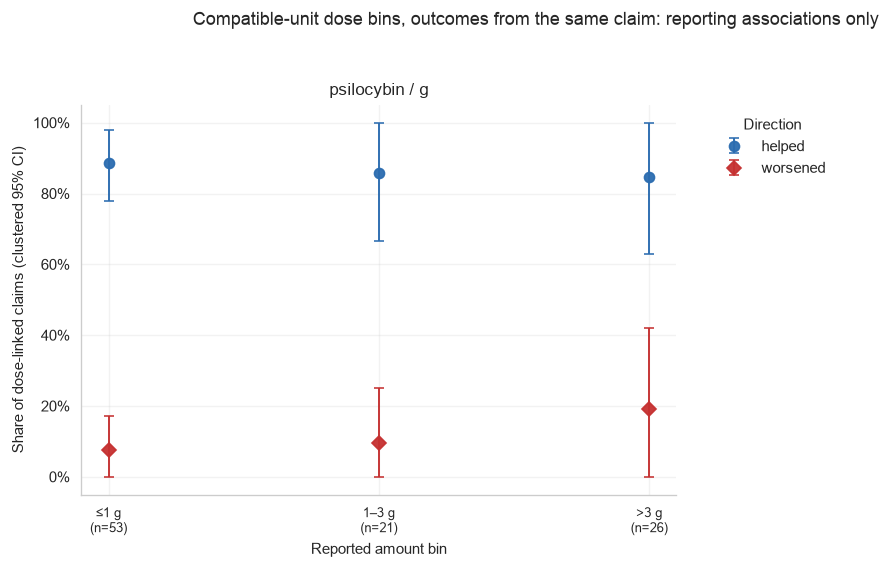

In [25]:
fig, axes = plt.subplots(1, len(dose_bin_order), figsize=(9, 4.5), sharey=True, squeeze=False)
for ax, (group, order) in zip(axes[0], dose_bin_order.items()):
    for outcome, color, marker in [("helped", "#2b6cb0", "o"), ("worsened", "#c53030", "D")]:
        sub = (dose_bin_stats.query("`dose group` == @group and outcome == @outcome")
               .set_index("dose bin").reindex(order).dropna(subset=["rate"]))
        if sub.empty:
            continue
        x = np.arange(len(order))[[order.index(i) for i in sub.index]]
        rate = sub["rate"].to_numpy()
        yerr = np.vstack([rate - sub["ci low"].to_numpy(), sub["ci high"].to_numpy() - rate])
        thin = sub["evidence"].eq("thin").to_numpy()
        ax.errorbar(x, rate, yerr=yerr, fmt=marker, color=color, capsize=3, linewidth=1.2,
                    alpha=0.45 if thin.all() else 0.95, label=outcome)
    ax.set_xticks(np.arange(len(order)), [
        f"{name}\n(n={int(dose_bin_stats.query('`dose group` == @group and outcome == \"helped\" and `dose bin` == @name')['n'].sum())})"
        for name in order], rotation=0, fontsize=8)
    thin_group = dose_bin_stats.query("`dose group` == @group")["evidence"].eq("thin").all()
    ax.set_title(f"{group}" + ("\n(all bins thin — not interpreted)" if thin_group else ""),
                 fontsize=10)
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
    ax.set_xlabel("Reported amount bin")
axes[0][0].set_ylabel("Share of dose-linked claims (clustered 95% CI)")
axes[0][-1].legend(title="Direction", bbox_to_anchor=(1.05, 1), loc="upper left", frameon=False)
fig.suptitle("Compatible-unit dose bins, outcomes from the same claim: "
             "reporting associations only", y=1.04)
fig.tight_layout(rect=[0, 0, 0.8, 1])
display(fig)
plt.close(fig)

In [26]:
# Each dose bin against the lowest bin of its own group: difference in
# percentage points with a reporter-clustered interval, ranked by magnitude.
dose_contrast_rows = []
for group, order in dose_bin_order.items():
    sub = dose_bin_outcomes[dose_bin_outcomes["dose group"].eq(group)]
    reference = order[0]
    for outcome in ["helped", "worsened"]:
        for other in order[1:]:
            pair = sub[sub["dose bin"].isin([reference, other])]
            mask = pair["dose bin"].eq(other)
            result = clustered_difference(pair, outcome, mask,
                                          seed=seed_for("dosediff", group, other, outcome))
            if not result:
                continue
            dose_contrast_rows.append({
                "dose group": group, "outcome": outcome,
                "comparison": f"{other} vs {reference}",
                "n comparison": result["focal rows"], "n reference": result["reference rows"],
                "difference (pp)": result["difference (pp)"],
                "diff low": result["diff low"], "diff high": result["diff high"],
                "Cohen h": result["Cohen h"],
                "interval": interval_note(result["diff low"], result["diff high"]),
                "evidence": "ok" if meets_gate(result["focal rows"], result["focal patients"])
                            else "thin",
            })
dose_contrasts = pd.DataFrame(dose_contrast_rows)
dose_contrasts = dose_contrasts.reindex(
    dose_contrasts["difference (pp)"].abs().sort_values(ascending=False).index)
display(dose_contrasts.style.format({
    "difference (pp)": "{:+.1f}", "diff low": "{:+.1f}", "diff high": "{:+.1f}",
    "Cohen h": "{:+.2f}",
}).hide(axis="index"))

thin = dose_contrasts.query("evidence == 'thin'")
display(HTML(
    f"<p><strong>Plain-language verdict.</strong> These panels only show how reported outcomes "
    f"differ across bins that share a drug <em>and</em> a unit, using only outcomes reported in "
    f"the same claim as the dose. "
    f"{len(thin)} of {len(dose_contrasts)} bin comparisons sit below the evidence gate and are "
    f"marked thin; LSD and ketamine are absent entirely for insufficient data once the linkage "
    f"is claim-level. Amount ranges stored as lower bounds, extraction error, and confounding by "
    f"indication and unmeasured setting make every row above unsuitable for dose selection. No "
    f"comparison here supports the claim that a higher dose caused a different outcome, and no "
    f"dose-response relationship is estimated — chronology is not recoverable from this dataset "
    f"at all.</p>"
))

dose group,outcome,comparison,n comparison,n reference,difference (pp),diff low,diff high,Cohen h,interval,evidence
psilocybin / g,worsened,>3 g vs ≤1 g,26,53,+11.7,-10.3,+36.7,+0.35,interval spans 0,ok
psilocybin / g,helped,>3 g vs ≤1 g,26,53,-4.1,-29.0,+15.7,-0.12,interval spans 0,ok
psilocybin / g,helped,1–3 g vs ≤1 g,21,53,-3.0,-27.3,+16.9,-0.09,interval spans 0,ok
psilocybin / g,worsened,1–3 g vs ≤1 g,21,53,+2.0,-12.3,+19.1,+0.07,interval spans 0,ok


## 8. Robustness and extraction sensitivity

The main sensitivity checks use the same pair-level outcome definitions while changing which
records are included: all extracted records, high-confidence effect records only, removal of
the three most prolific reporter-drug pairs by included-claim count, and patients who report
only one target drug. Clustered bootstrap intervals are used throughout. These checks test
stability of reporting summaries; they do not repair unvalidated extraction.

In [27]:
claim_pair_counts = actual_claims.groupby(["patient", "drug"]).size().sort_values(ascending=False)
prolific_pairs = set(claim_pair_counts.head(3).index)
single_drug_counts = actual_pairs.groupby("patient")["drug"].nunique()
single_drug_patients = set(single_drug_counts[single_drug_counts.eq(1)].index)


def pair_summary(effect_records, label):
    if effect_records.empty:
        return pd.DataFrame()
    grouped = effect_records.groupby(["patient", "drug"]).agg(
        helped=("direction", lambda s: (s == "helped").any()),
        worsened=("direction", lambda s: (s == "worsened").any()),
        n_effects=("direction", "size"),
    ).reset_index()
    rows = []
    for drug in DRUGS:
        sub = grouped[grouped["drug"].eq(drug)]
        for outcome in ["helped", "worsened"]:
            rate, lo, hi = clustered_rate(sub, outcome, seed=seed_for("robust", label, drug, outcome))
            rows.append({
                "scenario": label, "drug": drug, "outcome": outcome,
                "k": int(sub[outcome].sum()), "n": len(sub),
                "patients": sub["patient"].nunique(),
                "rate": rate, "ci low": lo, "ci high": hi,
                "evidence": "ok" if meets_gate(len(sub), sub["patient"].nunique()) else "insufficient",
            })
    return pd.DataFrame(rows)


without_prolific = effects[~effects.set_index(["patient", "drug"]).index.isin(prolific_pairs)]
single_drug_effects = effects[effects["patient"].isin(single_drug_patients)]
robustness = pd.concat([
    pair_summary(effects, "all actual-use effects"),
    pair_summary(effects[effects["confidence"].eq("high")], "high-confidence effects"),
    pair_summary(without_prolific, "remove 3 prolific pairs"),
    pair_summary(single_drug_effects, "single-target-drug patients"),
], ignore_index=True)

robustness_display = robustness.copy()
robustness_display["rate"] = robustness_display["rate"].map("{:.1%}".format)
robustness_display["clustered 95% CI"] = [
    f"{lo:.1%}-{hi:.1%}" if pd.notna(lo) else "-"
    for lo, hi in zip(robustness["ci low"], robustness["ci high"])
]
display(robustness_display[["scenario", "drug", "outcome", "k", "n", "patients", "rate",
                            "clustered 95% CI", "evidence"]].style.hide(axis="index"))

scenario,drug,outcome,k,n,patients,rate,clustered 95% CI,evidence
all actual-use effects,psilocybin,helped,304,341,341,89.1%,85.6%-92.4%,ok
all actual-use effects,psilocybin,worsened,32,341,341,9.4%,6.7%-12.3%,ok
all actual-use effects,ketamine,helped,294,352,352,83.5%,79.5%-87.5%,ok
all actual-use effects,ketamine,worsened,30,352,352,8.5%,5.7%-11.6%,ok
all actual-use effects,lsd,helped,46,54,54,85.2%,75.9%-94.4%,ok
all actual-use effects,lsd,worsened,4,54,54,7.4%,1.9%-14.8%,ok
high-confidence effects,psilocybin,helped,242,278,278,87.1%,83.1%-90.7%,ok
high-confidence effects,psilocybin,worsened,31,278,278,11.2%,7.6%-14.8%,ok
high-confidence effects,ketamine,helped,234,291,291,80.4%,75.6%-84.9%,ok
high-confidence effects,ketamine,worsened,30,291,291,10.3%,6.9%-14.1%,ok


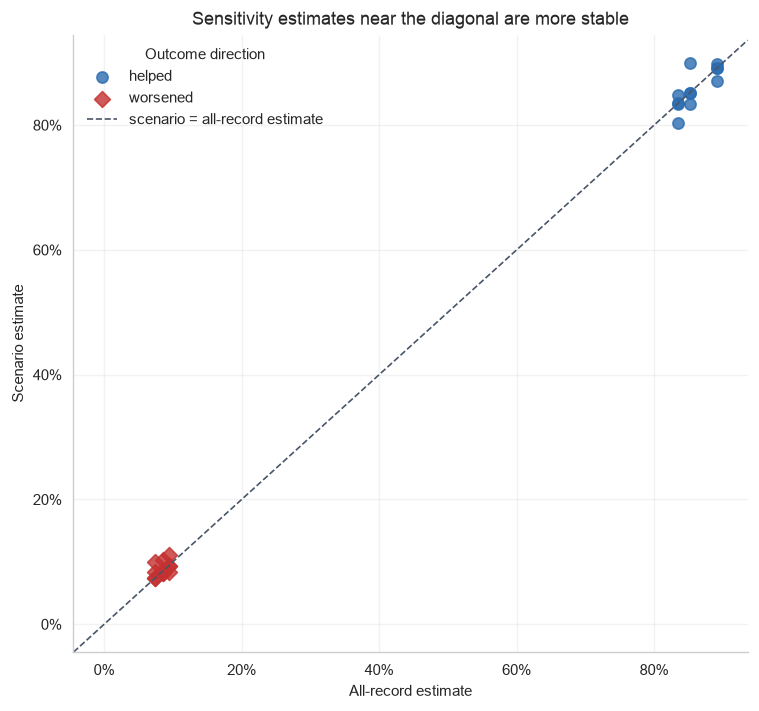

In [28]:
all_rates = robustness.query("scenario == 'all actual-use effects'").set_index(
    ["drug", "outcome"])["rate"]
robustness_delta = robustness.assign(
    baseline=[all_rates.get((r.drug, r.outcome), np.nan) for r in robustness.itertuples()]
)
robustness_delta["difference from all"] = (
    robustness_delta["rate"] - robustness_delta["baseline"])

fig, ax = plt.subplots(figsize=(6.4, 6))
for outcome, color, marker in [("helped", "#2b6cb0", "o"), ("worsened", "#c53030", "D")]:
    sub = robustness_delta[robustness_delta["outcome"].eq(outcome)]
    ax.scatter(sub["baseline"], sub["rate"], color=color, marker=marker, s=45,
               alpha=0.8, label=outcome)
ax.axline((0, 0), slope=1, color="#4a5568", linestyle="--", linewidth=1,
          label="scenario = all-record estimate")
ax.set_xlabel("All-record estimate")
ax.set_ylabel("Scenario estimate")
ax.set_title("Sensitivity estimates near the diagonal are more stable")
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
ax.legend(title="Outcome direction", frameon=False)
fig.tight_layout()
display(fig)
plt.close(fig)

In [29]:
gated_scenarios = robustness_delta.query("evidence == 'ok'").copy()
gated_scenarios["shift (pp)"] = 100 * gated_scenarios["difference from all"]
largest_deltas = gated_scenarios.reindex(
    gated_scenarios["shift (pp)"].abs().sort_values(ascending=False).index)
display(largest_deltas[["scenario", "drug", "outcome", "n", "patients", "rate", "shift (pp)"]]
        .style.format({"rate": "{:.1%}", "shift (pp)": "{:+.1f}"}).hide(axis="index"))

lead = largest_deltas.iloc[0]
dropped = len(robustness_delta) - len(gated_scenarios)
display(HTML(
    f"<p><strong>Robustness verdict.</strong> Across scenario estimates that clear the evidence "
    f"gate, the largest shift from the all-record estimate is "
    f"{lead['shift (pp)']:+.1f} percentage points ({lead['drug']} / {lead['outcome']}, "
    f"{lead['scenario']}, n={int(lead['n'])}). Shifts of this size are a reminder that cluster "
    f"composition and extraction confidence move these summaries; they are not a validation of "
    f"them. "
    + (f"{dropped} scenario estimates fall below the evidence gate and are omitted rather than "
       f"reported as stable. " if dropped else
       "Every scenario estimate shown clears the evidence gate, but LSD clears it only barely "
       "and its shifts are the least stable on the list. ")
    + "</p>"
))

scenario,drug,outcome,n,patients,rate,shift (pp)
single-target-drug patients,lsd,helped,30,30,90.0%,+4.8
high-confidence effects,ketamine,helped,291,291,80.4%,-3.1
single-target-drug patients,lsd,worsened,30,30,10.0%,+2.6
high-confidence effects,psilocybin,helped,278,278,87.1%,-2.1
high-confidence effects,lsd,helped,48,48,83.3%,-1.9
high-confidence effects,ketamine,worsened,291,291,10.3%,+1.8
high-confidence effects,psilocybin,worsened,278,278,11.2%,+1.8
single-target-drug patients,ketamine,helped,316,316,84.8%,+1.3
single-target-drug patients,psilocybin,worsened,296,296,8.4%,-0.9
high-confidence effects,lsd,worsened,48,48,8.3%,+0.9


## 9. Patterns worth investigating

This is a **magnitude-ranked screen**, not a test. It ranks the one-factor contrasts of §3 —
each cell against the same drug's other symptom classes, and each cell against the other drugs
inside the same symptom class — reported as differences in percentage points with
reporter-clustered bootstrap intervals and Cohen's *h*. Cells below the evidence gate never enter
the ranking. There is no p-value, no false-discovery-rate adjustment, and no threshold that
promotes a row to a finding.

**The comparison changed.** An earlier version compared each drug-symptom cell against the whole
rest of the corpus, which moved drug, symptom class, indication, route, access pattern and
reporter composition all at once; a difference from that reference could not be read as a
statement about the symptom class. Every row below holds one of those fixed. The two comparisons
are ranked separately and are not pooled.

**One scan was removed.** An earlier version also screened drug × adverse-event-category against
the `worsened` direction and reported nine "FDR survivors" as its leading results. Those
comparisons are close to tautological: an adverse-event record and a worsened effect direction
are routinely extracted from the same passage, so pairs that report an anxiety or fatigue event
are nearly guaranteed to also carry a worsened direction. The leading such row rested on **two
reporter accounts** and cleared its threshold anyway, which is a good illustration of why
multiplicity adjustment does not rescue a screen whose inputs are not independent. That scan is
gone; §5 retains the overlap only as a description.

The screen is also **direction-aware**. A cell can deviate by reporting *less* benefit, and the
sign is printed in every row and every sentence.

comparison,drug,symptom class,direction,direction of deviation,focal rows,focal patients,rate (focal),rate (reference),reference rows,difference (pp),diff low,diff high,Cohen h,interval,note
within drug,ketamine,fatigue_general,helped,below reference,35,35,37.1%,83.5%,541,-46.4,-60.4,-30.1,-1.00,interval below 0,
within symptom,ketamine,fatigue_general,helped,below reference,35,35,37.1%,71.9%,32,-34.7,-57.6,-11.5,-0.71,interval below 0,
within symptom,psilocybin,fatigue_general,helped,above reference,23,23,73.9%,43.2%,44,+30.7,+7.1,+54.3,+0.64,interval above 0,
within drug,psilocybin,fatigue_general,helped,below reference,23,23,73.9%,87.2%,507,-13.3,-33.3,+4.2,-0.34,interval spans 0,
within drug,ketamine,fatigue_general,worsened,above reference,35,35,17.1%,6.1%,541,+11.0,-0.4,+24.3,+0.35,interval spans 0,
within drug,ketamine,mood_cognitive,helped,above reference,155,155,87.7%,78.1%,421,+9.6,+3.4,+15.6,+0.26,interval above 0,
within drug,ketamine,pain,helped,above reference,78,78,88.5%,79.5%,498,+8.9,+1.2,+16.7,+0.25,interval above 0,
within drug,psilocybin,mood_cognitive,helped,above reference,131,131,93.1%,84.5%,399,+8.7,+3.0,+14.3,+0.28,interval above 0,
within symptom,ketamine,fatigue_general,worsened,above reference,35,35,17.1%,9.4%,32,+7.8,-9.0,+23.7,+0.23,interval spans 0,
within drug,psilocybin,pain,worsened,below reference,29,29,0.0%,7.6%,501,-7.6,-10.4,-5.1,-0.56,interval below 0,boundary rate — interval unreliable


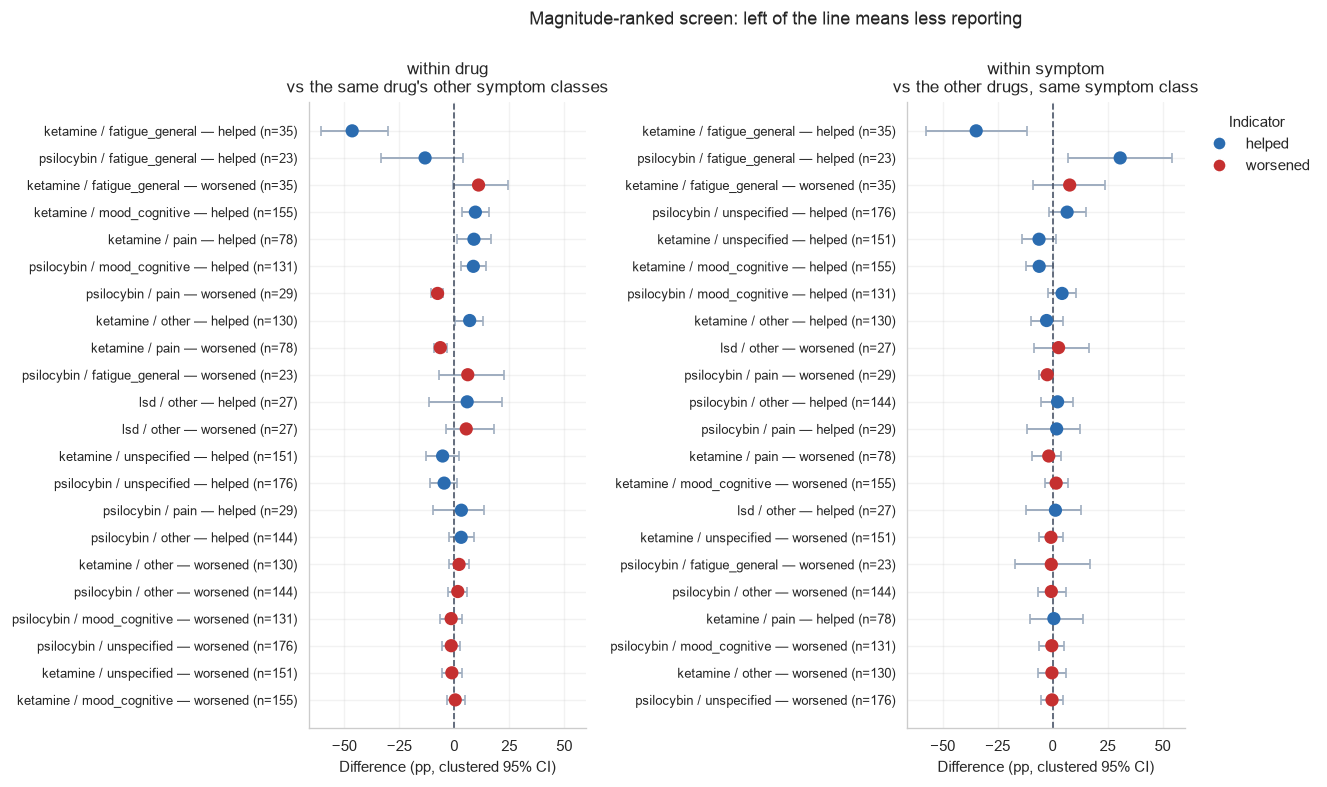

In [30]:
screen = contrasts.query("evidence == 'ok'").copy()
screen["direction of deviation"] = np.where(
    screen["difference (pp)"] > 0, "above reference", "below reference")
screen = screen.reindex(screen["|difference|"].sort_values(ascending=False).index)
display(
    screen[["comparison", "drug", "symptom class", "direction", "direction of deviation",
            "focal rows", "focal patients", "rate (focal)", "rate (reference)",
            "reference rows", "difference (pp)", "diff low", "diff high", "Cohen h",
            "interval", "note"]]
    .style.format({"rate (focal)": "{:.1%}", "rate (reference)": "{:.1%}",
                   "difference (pp)": "{:+.1f}", "diff low": "{:+.1f}",
                   "diff high": "{:+.1f}", "Cohen h": "{:+.2f}"})
    .hide(axis="index")
)

fig, axes = plt.subplots(1, 2, figsize=(13, 6.5), sharex=True)
for ax, kind, subtitle in [
    (axes[0], "within drug", "vs the same drug's other symptom classes"),
    (axes[1], "within symptom", "vs the other drugs, same symptom class"),
]:
    plot_screen = screen.query("comparison == @kind").iloc[::-1]
    y = np.arange(len(plot_screen))
    colors = ["#2b6cb0" if d == "helped" else "#c53030" for d in plot_screen["direction"]]
    ax.errorbar(plot_screen["difference (pp)"], y,
                xerr=np.vstack([plot_screen["difference (pp)"] - plot_screen["diff low"],
                                plot_screen["diff high"] - plot_screen["difference (pp)"]]),
                fmt="none", ecolor="#a0aec0", capsize=3, linewidth=1.2)
    ax.scatter(plot_screen["difference (pp)"], y, c=colors, s=48, zorder=3)
    ax.axvline(0, color="#4a5568", linestyle="--", linewidth=1)
    ax.set_yticks(y, [f"{r['drug']} / {r['symptom class']} — {r['direction']} "
                      f"(n={int(r['focal rows'])})" for _, r in plot_screen.iterrows()],
                  fontsize=8)
    ax.set_xlabel("Difference (pp, clustered 95% CI)")
    ax.set_title(f"{kind}\n{subtitle}", fontsize=10)
handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markersize=8, label=l)
           for l, c in [("helped", "#2b6cb0"), ("worsened", "#c53030")]]
axes[1].legend(handles=handles, title="Indicator", bbox_to_anchor=(1.02, 1), loc="upper left",
               frameon=False)
fig.suptitle("Magnitude-ranked screen: left of the line means less reporting", y=1.0)
fig.tight_layout(rect=[0, 0, 0.86, 1])
display(fig)
plt.close(fig)

In [31]:
clear = screen.query("interval != 'interval spans 0' and not boundary").copy()
boundary = screen.query("interval != 'interval spans 0' and boundary").copy()
boundary_note = ""
if not boundary.empty:
    boundary_note = (
        " Separately, "
        + "; ".join(f"{r['drug']} / {r['symptom class']} ({r['direction']} "
                    f"{r['rate (focal)']:.0%} of {int(r['focal rows'])} rows, {r['comparison']})"
                    for _, r in boundary.iterrows())
        + (" sits" if len(boundary) == 1 else " sit")
        + " at a boundary rate of 0% or 100%. Such an interval is set entirely by the "
          "comparison arm rather than by any variation of its own, so it is excluded from "
          "the ranking above rather than reported as a separated cell."
    )
if clear.empty:
    sentence = (
        "No gated contrast has a difference interval clear of zero. Every pattern in the screen "
        "is compatible with no deviation from its reference at this sample size, so this "
        "notebook names no candidate for validation." + boundary_note
    )
else:
    lead = clear.iloc[0]
    sign = "above" if lead["difference (pp)"] > 0 else "below"
    reference = ("the same drug's other symptom classes" if lead["comparison"] == "within drug"
                 else "the other drugs in the same symptom class")
    others = "; ".join(
        f"{r['drug']} / {r['symptom class']} ({r['direction']}, {r['comparison']}, "
        f"{r['difference (pp)']:+.1f} pp)" for _, r in clear.iloc[1:].iterrows()
    )
    sentence = (
        f"{len(clear)} of {len(screen)} gated contrasts have a difference interval clear of "
        f"zero without sitting at a boundary rate. The largest is {lead['drug']} / "
        f"{lead['symptom class']}, where {lead['direction']}-reporting runs "
        f"{abs(lead['difference (pp)']):.1f} percentage points {sign} {reference} "
        f"({lead['rate (focal)']:.1%} vs {lead['rate (reference)']:.1%}; interval "
        f"{lead['diff low']:+.1f} to {lead['diff high']:+.1f} pp; Cohen h="
        f"{lead['Cohen h']:+.2f}; n={int(lead['focal rows'])} rows from "
        f"{int(lead['focal patients'])} reporter accounts). Read the sign: this is a deficit in "
        f"reported benefit for that symptom class, not evidence of benefit. "
        + (f"The remaining separated contrasts are {others}. " if others else "")
        + "Each is an observational extraction signal worth human validation, not a causal or "
        "clinical conclusion, and 'interval clear of zero' is a description of the interval, "
        "not a significance test." + boundary_note
    )
display(HTML(
    f"<h3>Patterns Worth Investigating</h3><p>{html.escape(sentence)}</p>"
))

## 10. Reporting-signal tiers

These tiers prioritize patterns for validation, not treatments for patients. They are built from
two ingredients and no test:

1. **Evidence volume** — a cell must clear the gate (≥20 rows, ≥10 reporter accounts) to be
   tiered at all; below that it is `Insufficient evidence`, whatever its point estimate looks
   like.
2. **Separation and direction** — where the **contrast's own** bootstrap interval sits relative
   to zero. The reference is the same drug's other symptom classes, so a tier moves one factor,
   and both arms are recomputed inside every resample of whole accounts.

The result is four labels: `Above the drug's other symptom classes`, `Below the drug's other
symptom classes`, `Consistent with the drug's other symptom classes`, and `Insufficient
evidence`. **A tier is never a quality judgement and never implies benefit** — a `Below` tier
marks a cell where people report *less* improvement, which is exactly as interesting for
validation and the opposite in clinical meaning.

Three things from earlier drafts are gone. A two-sided binomial p-value against the pooled rate
promoted below-baseline cells to "Strong reporting signal" with no sign attached, and an
`n ≥ 15 or p < 0.10` rule promoted a cell whose rate was not separated to "Moderate reporting
signal" on sample size alone. The reporting-NNT-analog column is also removed: with no control
arm there is no number needed to treat, and the column read as one while silently blanking for
every below-baseline cell. Most recently, the tier compared a cell's *marginal* interval against
a corpus rate treated as a known constant — which ignored the uncertainty in the comparator and
the accounts shared between the two sides, and could hand a cell a stronger tier than the data
support. Tiers now come from the contrast distribution itself.

In [32]:
# Tiers read the contrast's own bootstrap distribution: each resample recomputes
# the focal cell and its reference arm together, so the comparator carries its
# uncertainty and an account with rows on both sides stays in one cluster.
TIER_ORDER = ["Above the drug's other symptom classes",
              "Below the drug's other symptom classes",
              "Consistent with the drug's other symptom classes",
              "Insufficient evidence"]

tier_rows = []
for _, row in symptom_stats.query("direction == 'helped'").iterrows():
    contrast = cell_rows(within_drug, row["drug"], row["symptom class"])
    c = contrast.iloc[0] if not contrast.empty else None
    if row["evidence"] != "ok" or c is None:
        tier = "Insufficient evidence"
    elif c["diff low"] > 0:
        tier = TIER_ORDER[0]
    elif c["diff high"] < 0:
        tier = TIER_ORDER[1]
    else:
        tier = TIER_ORDER[2]
    tier_rows.append({
        "drug": row["drug"], "symptom class": row["symptom class"], "k": int(row["k"]),
        "rows": int(row["rows"]), "reporter accounts": int(row["patients"]),
        "helped share": row["rate"],
        "reference share": c["rate (reference)"] if c is not None else np.nan,
        "difference (pp)": c["difference (pp)"] if c is not None else np.nan,
        "diff low": c["diff low"] if c is not None else np.nan,
        "diff high": c["diff high"] if c is not None else np.nan,
        "Cohen h": c["Cohen h"] if c is not None else np.nan,
        "tier": tier,
    })
tiers = pd.DataFrame(tier_rows)
tiers["tier"] = pd.Categorical(tiers["tier"], TIER_ORDER, ordered=True)
tiers = tiers.sort_values(["tier", "rows"], ascending=[True, False])
display(tiers.style.format({
    "helped share": "{:.1%}", "reference share": "{:.1%}", "difference (pp)": "{:+.1f}",
    "diff low": "{:+.1f}", "diff high": "{:+.1f}", "Cohen h": "{:+.2f}",
}, na_rep="—").hide(axis="index"))

counts = tiers["tier"].value_counts().reindex(TIER_ORDER, fill_value=0)
display(HTML(
    "<p><strong>Tier summary.</strong> "
    + "; ".join(f"{label}: {int(counts[label])}" for label in TIER_ORDER)
    + ". The below-reference cells are the ones to validate first, because a symptom class "
      "where people report less improvement is the claim most likely to be wrong in a way that "
      "matters.</p>"
))

drug,symptom class,k,rows,reporter accounts,helped share,reference share,difference (pp),diff low,diff high,Cohen h,tier
ketamine,mood_cognitive,136,155,155,87.7%,78.1%,+9.6,+3.4,+15.6,+0.26,Above the drug's other symptom classes
psilocybin,mood_cognitive,122,131,131,93.1%,84.5%,+8.7,+3.0,+14.3,+0.28,Above the drug's other symptom classes
ketamine,other,112,130,130,86.2%,79.1%,+7.0,+0.5,+13.3,+0.19,Above the drug's other symptom classes
ketamine,pain,69,78,78,88.5%,79.5%,+8.9,+1.2,+16.7,+0.25,Above the drug's other symptom classes
ketamine,fatigue_general,13,35,35,37.1%,83.5%,-46.4,-60.4,-30.1,-1.00,Below the drug's other symptom classes
psilocybin,unspecified,147,176,176,83.5%,88.1%,-4.6,-11.1,+1.4,-0.13,Consistent with the drug's other symptom classes
ketamine,unspecified,116,151,151,76.8%,82.1%,-5.3,-12.8,+2.3,-0.13,Consistent with the drug's other symptom classes
psilocybin,other,128,144,144,88.9%,85.8%,+3.1,-2.5,+8.8,+0.09,Consistent with the drug's other symptom classes
psilocybin,pain,26,29,29,89.7%,86.4%,+3.2,-9.6,+13.6,+0.10,Consistent with the drug's other symptom classes
lsd,other,24,27,27,88.9%,83.0%,+5.9,-11.7,+21.8,+0.17,Consistent with the drug's other symptom classes


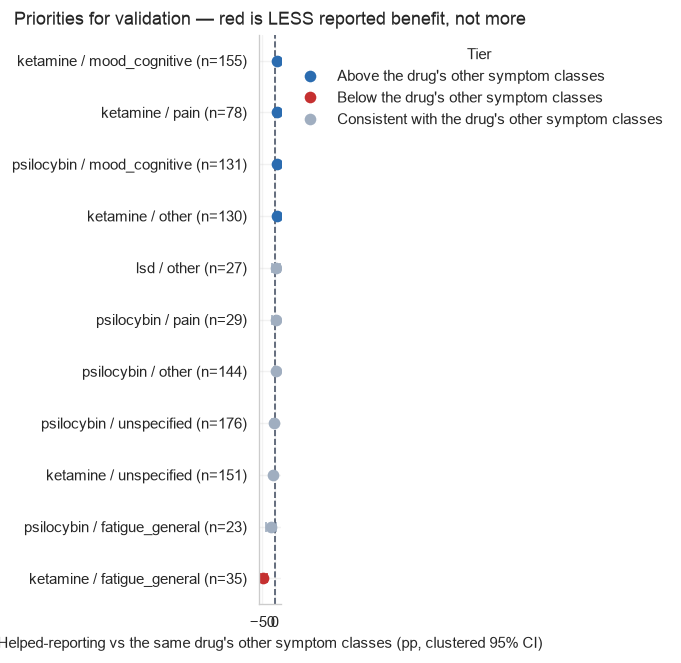

In [33]:
tier_plot = tiers.query("tier != 'Insufficient evidence'").sort_values("difference (pp)").copy()
tier_colors = {
    TIER_ORDER[0]: "#2b6cb0",
    TIER_ORDER[1]: "#c53030",
    TIER_ORDER[2]: "#a0aec0",
}
fig, ax = plt.subplots(figsize=(9.5, 5.6))
y = np.arange(len(tier_plot))
for yi, (_, row) in enumerate(tier_plot.iterrows()):
    ax.errorbar(row["difference (pp)"], yi,
                xerr=[[row["difference (pp)"] - row["diff low"]],
                      [row["diff high"] - row["difference (pp)"]]],
                fmt="o", color=tier_colors[row["tier"]], capsize=3, markersize=6)
ax.axvline(0, color="#4a5568", linestyle="--", linewidth=1)
ax.set_yticks(y, [f"{r['drug']} / {r['symptom class']} (n={int(r['rows'])})"
                  for _, r in tier_plot.iterrows()])
ax.set_xlabel("Helped-reporting vs the same drug's other symptom classes "
              "(pp, clustered 95% CI)")
ax.set_title("Priorities for validation — red is LESS reported benefit, not more")
handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=color, markersize=8,
                      label=label) for label, color in tier_colors.items()]
ax.legend(handles=handles, title="Tier", bbox_to_anchor=(1.02, 1), loc="upper left",
          frameon=False)
fig.tight_layout(rect=[0, 0, 0.62, 1])
display(fig)
plt.close(fig)
display(HTML(
    f"<p>Cells below the evidence gate are omitted from this chart entirely "
    f"({int((tiers['tier'] == 'Insufficient evidence').sum())} of {len(tiers)}), rather than "
    f"plotted with an interval spanning most of the axis.</p>"
))

## What patients are saying

This notebook cannot responsibly reproduce patient quotes: the v2 loader deliberately strips
`source_window.text`, evidence quotes, author hashes, and free-text dose fields before data
reach the analysis. The quantitative categories above are therefore the complete patient-
experience evidence available to this privacy-safe notebook. A follow-up qualitative study
would need a separately privacy-reviewed raw corpus, timestamps, source relationships, and
manual quote redaction; it should not be reconstructed from this output.

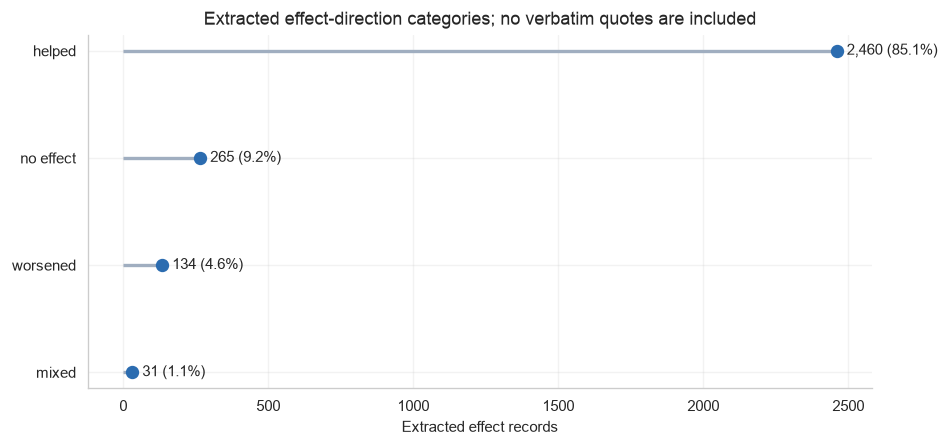

In [34]:
direction_counts = effects["direction"].value_counts().reindex(DIRECTIONS, fill_value=0)
fig, ax = plt.subplots(figsize=(8, 3.8))
total_directions = direction_counts.sum()
y = np.arange(len(direction_counts))
ax.hlines(y, 0, direction_counts.to_numpy(), color="#a0aec0", linewidth=2)
ax.plot(direction_counts.to_numpy(), y, "o", color="#2b6cb0", markersize=7)
for yi, count in zip(y, direction_counts):
    ax.annotate(f"{int(count):,} ({count / total_directions:.1%})",
                (count, yi), xytext=(6, 0), textcoords="offset points",
                va="center", fontsize=9)
ax.set_yticks(y, [direction.replace("_", " ") for direction in DIRECTIONS])
ax.invert_yaxis()
ax.set_xlabel("Extracted effect records")
ax.set_title("Extracted effect-direction categories; no verbatim quotes are included")
fig.tight_layout()
display(fig)
plt.close(fig)


## 11. Conclusion

Among self-reported actual-use reporter-drug pairs in this v2 probe, the defensible answer is
that experiences are heterogeneous and **symptom-specific in a direction that matters**. Helped
directions dominate overall — roughly six in seven effect-bearing pairs report at least one.
Across the three drugs the any-helped shares are close together and their intervals overlap;
because **no equivalence margin was prespecified and no equivalence test was performed**, that is
reported here as a set of descriptive estimates with overlapping uncertainty and **not** as
evidence that the drugs perform alike. The pairwise differences and their intervals are shown in
§4 for the reader to judge; an overlap is a statement about precision, not about sameness.

The one pattern that separates is a deficit rather than a benefit, and it is about
**nonspecific fatigue**: holding the drug fixed, helped-reporting for the general-fatigue class
falls well below ketamine's other symptom classes, and holding the symptom class fixed, ketamine
falls below the other drugs within it. Two contrasts moving different factors agree in sign, and
a reporter-clustered interaction model puts the general-fatigue main effect clearly below zero
while leaving the ketamine-specific increment imprecise — so the better-supported statement is
that *fatigue attracts less reported benefit*, with ketamine the sharpest case rather than a
separate finding. Mood/cognitive runs the other way, above the other classes for psilocybin.

**This is deliberately not a PEM result.** Post-exertional malaise is a specific delayed
worsening after exertion and is the outcome a post-viral cohort most wants an answer about, but
targets that actually state it are rare here: every explicit-PEM cell falls below the evidence
gate for every drug, and none is estimated. An earlier version of this notebook reported the
deficit as an energy/PEM finding because one regular expression put explicit PEM, exertion
intolerance, ordinary fatigue and low energy in a single class. Separated, that class is mostly
ordinary fatigue. The finding above is worth validating; it is not evidence about PEM.

Alongside that, no-effect, worsened, and mixed/conflicting profiles coexist throughout:
benefit-plus-harm pairs are a substantive outcome and are not collapsed into treatment success.
Adverse-event records coexist with both helped and worsened profiles, and any-event shares vary
by drug. Ketamine's stated routes are majority IV/IM, and injected use plausibly travels with a
different reporting context than oral self-administration — but **this run records no
administration-setting field**, so that remains an untested explanation rather than a finding,
and no difference in this notebook is attributed to supervision.

The main practical constraint is coverage. Only 9.1% of effect records state a duration, and
numeric amount-plus-unit records are sparse and not commensurable across drugs. Linking each dose
to outcomes extracted from **its own claim** — rather than to its reporter's overall outcome
summary — leaves psilocybin in grams as the only subset thick enough to bin; **ketamine in
milligrams and LSD are both reported as insufficient data**. Within psilocybin the binned
reporting rates are close to flat across ≤1 g, 1–3 g, and >3 g, and no dose-response relationship
is estimated or implied. Route is reported for ketamine only, as a stated route. Sensitivity
checks on high-confidence records, prolific pairs, and single-target-drug reporters indicate how
much these summaries depend on extraction and reporter composition — not whether any drug is
effective.

These results support a narrow position: symptom-specific, harm-aware, direction-aware extraction
is more informative than a single positive label, and the general-fatigue deficit is the pattern
to human-validate first — starting with whether the extractor's fatigue targets mean what the
class name says. This notebook reports no p-values, tests no hypotheses, and cannot support
a reporter-specific treatment recommendation.

## 12. Research limitations

- **Selection bias:** the cohort consists of people whose Reddit reports were already
  associated with the target drugs; people who tried a drug and never posted are absent.
- **Reporting bias:** posting is not independent of outcome, and positive or adverse
  experiences may be disproportionately narrated.
- **Survivorship bias:** persistent users and people who continue participating can be
  overrepresented relative to people who stopped posting.
- **Recall bias:** extracted reports may summarize remembered experiences rather than records
  collected prospectively.
- **Confounding:** indication, illness severity, clinical supervision, co-treatments, dose,
  route, and access differ across drugs and are not controlled. Ketamine's majority IV/IM
  stated route is the clearest instance and is not adjusted for anywhere.
- **Setting is unmeasured:** this run records no structured administration-setting or
  supervision field. Route is not a proxy for one — intranasal esketamine is routinely
  supervised, and an injection label documents no supervision — so no result here is
  explained by clinic versus take-home administration.
- **Symptom classes are regular expressions over free text, not adjudicated codes:** a class
  says which words the target contained, not what the reporter meant. `pem_explicit` requires
  post-exertional language, but no human has checked whether those targets really describe
  post-exertional malaise, nor whether `fatigue_general` targets exclude it — the class
  precision is **unestimated**, because the targets themselves are quote-bearing text this
  notebook may not display. The consequence runs both ways: the fatigue deficit could be
  diluted PEM, and the absent PEM cells could be under-counted. Both need item-level
  validation against the source passages, which is the first thing to do with this result.
- **Identity:** an analysis unit is a Reddit account, not a verified person. Shared accounts,
  one person using several accounts, and misattributed self-reports are all possible and
  unmeasured, so account counts are an upper bound on distinct people and the clustering
  correction is only as good as the account-to-person mapping.
- **No equivalence testing:** where intervals for two drugs overlap, that is reported as
  overlapping uncertainty. No equivalence margin was prespecified and no equivalence test was
  run, so nothing here shows that two drugs perform alike.
- **No control group:** no untreated or comparator arm exists, so rates are not causal effects.
  For the same reason no number needed to treat is reported — an earlier draft carried a
  "reporting NNT analog" column, which has been removed rather than caveated.
- **Extraction labels are not clinical outcomes:** a `helped` or `worsened` label is the model's
  reading of a passage, not a validated outcome measure. No item-level validation of *this*
  extraction exists (see the validation-gate bullet), so the direction of any label bias in this
  run is **unmeasured**. An earlier draft asserted that positive labels are over-called by
  10–20%; that figure has no source in this repository and has been removed.
- **Extraction instability:** the v1 corpus documentation reports 36.5% field-set and 58.8%
  value agreement across two identical passes. That measurement was made on **v1's extraction of
  community-scored triples, not on this pipeline**, and no repeat-pass check was run here. It is
  carried as an order-of-magnitude warning about record-level stability, not as a measurement of
  this run — which means every interval in this notebook covers sampling only and understates
  total error.
- **Attribution:** this run extracts one claim per passage per target drug with a quote for each
  field, so v1's collective-outcome problem — one outcome in a post listing several drugs being
  attached to all of them — does not apply in the same form. Drug misattribution within a stack
  remains possible and is unmeasured; the single-target-drug sensitivity check in §8 is the only
  probe of it here.
- **Temporal snapshot:** this is one source snapshot and one extraction run, not a longitudinal
  follow-up. The snapshot date is the date in the snapshot's name; post timestamps are not
  loaded, so **the period the content was written in is unknown**. Treatment switching over
  time cannot be reconstructed, and no dose-response over time is estimable.
- **Missingness:** `not stated` is silence, not absence. Duration (91% unstated), numeric amount,
  route, intent, formulation, schedule, and context have uneven coverage. Once doses are linked
  to outcomes from their own claim, both LSD and ketamine numeric dosing are reported as
  insufficient rather than estimated, and route is reported for ketamine only.
- **Clustering:** claims and records are concentrated among reporters.
  Intervals here resample whole reporter accounts, which handles the dependence between arms of a
  comparison, but it does not remove the influence of a prolific reporter on a point estimate.
- **No hypothesis tests:** this notebook reports no p-values, chi-squared statistics, or
  false-discovery-rate adjustments. Comparisons are differences with clustered intervals ranked
  by magnitude. "Interval clear of zero" is a description of an interval, not a test decision,
  and none of the screens in §9 or §10 should be read as confirmatory.
- **Validation gate:** the prior v2 report states that human item-level validation was skipped.
  Mechanical quote grounding does not prove correct field attribution, drug attribution, or
  actual-use classification. The observed patterns are unvalidated.
- **Privacy boundary:** no verbatim quotes or author identifiers were carried into this
  notebook. A public release would require an explicit redaction review even if quotes were
  later added.

The database is a quote-bearing research artifact, while this notebook is a quote-free
aggregation. Its provenance block below records the exact data snapshot used to produce the
HTML export.

In [35]:
display(provenance.style.hide(axis="index").set_properties(**{"text-align": "left"}))
display(HTML(
    '<p><strong>Final interpretation:</strong> These findings should be used to prioritize '
    'validation questions and improve patient-experience measurement, not to select or reject '
    'a treatment for an individual.</p>'
))


item,value
database,psychedelic_pharmacology.db
database SHA-256,2edbe6136ec8c451e486ecd3d3b19cbdf1ed2e78e47a07c5a808f8cf137f96cc
run ID (pinned),710567555e22b68c025d8ceb1c3373564d7f9b01dcc5fe94b02b7c3209ecbc05
run created,2026-08-09T22:30:11.041289+00:00
model,deepseek/deepseek-v4-flash
provider / base URL,openai / https://openrouter.ai/api
source snapshot,reddit_2026-06-13.db (source snapshot documented by the v2 run)
source snapshot date,2026-06-13 (the date in the snapshot name)
content date range,unavailable — post timestamps are not loaded
execution date (UTC),2026-08-10


In [36]:
display(HTML(
    '<div style="font-size: 1.2em; font-weight: bold; font-style: italic; margin-top: 1em;">'
    'These findings reflect reporting patterns in online communities, not population-level '
    'treatment effects. This is not medical advice.'
    '</div>'
))
